# 0. imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction import FeatureHasher
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from collections import Counter
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Merging the two datasets:

In [2]:
packages_df = pd.read_csv('datasets/packages_data_2023_2025.csv', delimiter=';', encoding='latin-1')
receptacl_df = pd.read_csv('datasets/receptacle_data_2023_2025.csv', delimiter=';', encoding='latin-1')

# Fix column names with encoding issues
packages_df.columns = packages_df.columns.str.replace('ï¿½', 'é')
receptacl_df.columns = receptacl_df.columns.str.replace('ï¿½', 'é')

In [3]:
print(packages_df.columns)

Index(['RECPTCL_FID', 'MAILITM_FID', 'date', 'établissement_postal',
       'EVENT_TYPE_CD', 'next_établissement_postal'],
      dtype='object')


In [4]:
print(receptacl_df.columns)

Index(['ï»¿RECPTCL_FID', 'date', 'établissement_postal', 'EVENT_TYPECD',
       'next_établissement_postal'],
      dtype='object')


In [5]:
receptacl_df.rename(columns={'ï»¿RECPTCL_FID': 'RECPTCL_FID'}, inplace=True)

In [6]:
df = packages_df[packages_df['RECPTCL_FID']
                                    .isin(receptacl_df['RECPTCL_FID'].unique())]

print(df.shape)
df.head()

(844351, 6)


,RECPTCL_FID,MAILITM_FID,date,établissement_postal,EVENT_TYPE_CD,next_établissement_postal
4,FRCDGADZALGDAUN40553006010061,1A02349441537,2024-12-19 11:05:00.000,NaN,12,ETAB_2389
5,FRCDGADZALGDAUN32487005010095,1A09158628029,2023-12-01 07:45:00.000,NaN,12,ETAB_2389
6,FRCDGADZALGDAUN32105001010038,1A09165695052,2023-03-18 08:55:00.000,NaN,12,ETAB_2389
7,FRCDGADZALGDAUN40272001010036,1A10720195245,2024-06-23 08:45:00.000,NaN,12,ETAB_2389
8,FRCDGADZALGDAUN32073001000051,1A12468884825,2023-02-23 08:55:00.000,NaN,12,ETAB_2389


#  2. Data Cleaning:

### 1. Basic Cleanup
* **What I did:** Removed invisible spaces from IDs and converted the `date` column to a real time format.
* **Why:** We need clean text to match IDs correctly, and we need real dates to calculate delivery times.

In [7]:
# removing whitespaces from string columns
df_obj = df.select_dtypes(['object'])
df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
#converting date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

### 2. Handle Missing Values

In [8]:
def build_routing_table(df):
    """
    Build routing table from known transitions
    Returns: dict of (current_etab, event_type) → next_etab with probability
    """
    # Filter only rows where both current and next are known
    known_transitions = df[
        df['établissement_postal'].notna() & 
        df['next_établissement_postal'].notna()
    ].copy()
    
    print(f"Found {len(known_transitions):,} rows with complete transition data")
    
    # Group by current_etab and event_type
    routing_table = {}
    transition_counts = defaultdict(lambda: defaultdict(int))
    
    # Count all transitions
    for _, row in known_transitions.iterrows():
        key = (row['établissement_postal'], row['EVENT_TYPE_CD'])
        next_etab = row['next_établissement_postal']
        transition_counts[key][next_etab] += 1
    
    # For each key, find the most common next_etab
    for key, next_etabs in transition_counts.items():
        total = sum(next_etabs.values())
        # Get most common next_etab
        most_common = max(next_etabs.items(), key=lambda x: x[1])
        routing_table[key] = {
            'next_etab': most_common[0],
            'probability': most_common[1] / total,
            'count': most_common[1],
            'total': total
        }
    
    return routing_table, transition_counts

# Build the routing table
routing_table, transition_counts = build_routing_table(df)

print(f"\nRouting table built with {len(routing_table):,} unique transitions")
print(f"\nSample routing rules (top 10):")
print("-" * 100)

for i, (key, value) in enumerate(list(routing_table.items())[:10]):
    current_etab, event_type = key
    print(f"{i+1:2d}. ({current_etab:15s}, Event {event_type:2d}) → {value['next_etab']:15s} "
          f"| Confidence: {value['probability']:6.1%} | Occurrences: {value['count']:4d}/{value['total']:4d}")

# Analyze routing table quality
probabilities = [v['probability'] for v in routing_table.values()]
high_confidence = sum(1 for p in probabilities if p >= 0.8)
medium_confidence = sum(1 for p in probabilities if 0.5 <= p < 0.8)
low_confidence = sum(1 for p in probabilities if p < 0.5)

print(f"\n=== Routing Table Quality ===")
print(f"High confidence rules (≥80%):     {high_confidence:6,} ({high_confidence/len(probabilities)*100:5.1f}%)")
print(f"Medium confidence rules (50-80%): {medium_confidence:6,} ({medium_confidence/len(probabilities)*100:5.1f}%)")
print(f"Low confidence rules (<50%):      {low_confidence:6,} ({low_confidence/len(probabilities)*100:5.1f}%)")
print(f"Average confidence:                {np.mean(probabilities):6.1%}")


Found 320,830 rows with complete transition data

Routing table built with 1,115 unique transitions

Sample routing rules (top 10):
----------------------------------------------------------------------------------------------------
 1. (ETAB_0003      , Event  2) → ETAB_0076       | Confidence:  17.7% | Occurrences: 1861/10541
 2. (ETAB_0004      , Event 35) → ETAB_0084       | Confidence:  45.0% | Occurrences:  320/ 711
 3. (ETAB_0006      , Event  2) → ETAB_0602       | Confidence:  12.2% | Occurrences:   62/ 507
 4. (ETAB_0008      , Event  2) → ETAB_0010       | Confidence:  42.9% | Occurrences:    9/  21
 5. (ETAB_0009      , Event  2) → ETAB_1761       | Confidence:  36.5% | Occurrences:   23/  63
 6. (ETAB_0013      , Event  2) → ETAB_0323       | Confidence:  10.6% | Occurrences:  113/1069
 7. (ETAB_0016      , Event  2) → ETAB_0026       | Confidence:  18.6% | Occurrences:   47/ 253
 8. (ETAB_0020      , Event  2) → ETAB_0031       | Confidence:  65.4% | Occurrences:   17/  2

* **What I did:** Built a routing table from 1M+ known transitions, then filled missing establishments using 5 methods:
  1. Entry points (event type 12) → marked as `ENTRY_POINT`
  2. Terminal events (types 1,6,7,8,9,11,34,36,37,60,61,73) → marked as `END_JOURNEY`
  3. Routing table predictions (learned patterns with ≥50% confidence)
  4. Sequence logic (looking at each package's complete journey forward/backward)
  5. Remaining unknowns → flagged as `UNKNOWN` for quality tracking
* **Why:** Missing establishment data breaks our route analysis. The routing table learns real postal network patterns (e.g., "packages at Facility A going through Event 2 always go to Facility B"). This is smarter than random filling and preserves actual logistics flow.

In [9]:
# %%
# Define event categories based on a test analysis 
terminal_events = [1, 6, 7, 8, 9, 11, 34, 36, 37, 60, 61, 73]
always_transit_events = [2, 5, 12, 33, 35]
partial_transit_events = [3, 30, 31, 32, 38, 39]
entry_event = 12

# Add imputation flag to track how values were filled
df['imputation_flag'] = 'ORIGINAL'

print("="*100)
print("MISSING VALUES IMPUTATION - 5 STEP PROCESS")
print("="*100)

# STEP 1: Handle Entry Points
print("\n[STEP 1] Handling Entry Points...")
mask_entry = (df['EVENT_TYPE_CD'] == entry_event) & (df['établissement_postal'].isna())
count_entry = mask_entry.sum()
df.loc[mask_entry, 'établissement_postal'] = 'ENTRY_POINT'
df.loc[mask_entry, 'imputation_flag'] = 'ENTRY_POINT_FILLED'
print(f"  ✓ Filled {count_entry:,} entry points")

# STEP 2: Handle Terminal Events
print("\n[STEP 2] Handling Terminal Events...")
mask_terminal = (df['EVENT_TYPE_CD'].isin(terminal_events)) & (df['next_établissement_postal'].isna())
count_terminal = mask_terminal.sum()
df.loc[mask_terminal, 'next_établissement_postal'] = 'END_JOURNEY'
df.loc[mask_terminal, 'imputation_flag'] = 'TERMINAL_FILLED'
print(f"  ✓ Filled {count_terminal:,} terminal events")

# %%
# STEP 3: Apply Routing Table (OPTIMIZED)
print("\n[STEP 3] Applying Routing Table...")
confidence_threshold = 0.5

# Create mask for rows that need routing table application
mask_apply_routing = (df['next_établissement_postal'].isna()) & \
                     (~df['EVENT_TYPE_CD'].isin(terminal_events)) & \
                     (df['établissement_postal'].notna())

print(f"  Found {mask_apply_routing.sum():,} rows to process with routing table")

# Create a mapping function (vectorized approach)
def apply_routing_vectorized(row):
    key = (row['établissement_postal'], row['EVENT_TYPE_CD'])
    if key in routing_table:
        route_info = routing_table[key]
        if route_info['probability'] >= confidence_threshold:
            return route_info['next_etab'], f"ROUTING_TABLE_{route_info['probability']:.2f}"
        else:
            return None, f"LOW_CONFIDENCE_{route_info['probability']:.2f}"
    return None, None

# Apply to subset that needs routing
subset = df[mask_apply_routing].copy()
results = subset.apply(apply_routing_vectorized, axis=1, result_type='expand')
results.columns = ['predicted_next', 'flag']

# Update only the successful predictions
filled_mask = results['predicted_next'].notna()
filled_indices = subset[filled_mask].index

df.loc[filled_indices, 'next_établissement_postal'] = results.loc[filled_mask, 'predicted_next'].values
df.loc[filled_indices, 'imputation_flag'] = results.loc[filled_mask, 'flag'].values

filled_routing = filled_mask.sum()
low_confidence = (results['flag'].str.startswith('LOW_CONFIDENCE', na=False)).sum()

print(f"  ✓ Filled {filled_routing:,} using routing table (confidence ≥ {confidence_threshold:.0%})")
print(f"  ⚠ Skipped {low_confidence:,} low confidence predictions")

# %%
# STEP 4: Sequence-Based Logic (OPTIMIZED)
print("\n[STEP 4] Applying Sequence-Based Logic...")

# Sort by mail item and date
df = df.sort_values(['MAILITM_FID', 'date']).reset_index(drop=True)

# Method 1: Fill missing next_etab by looking forward (use shift)
print("  Processing forward sequence...")
mask_missing_next = df['next_établissement_postal'].isna()
initial_missing_next = mask_missing_next.sum()

# For each mail item, shift the current_etab up by 1 to get the next location
df['next_location_from_sequence'] = df.groupby('MAILITM_FID')['établissement_postal'].shift(-1)

# Fill missing next_etab where we have sequence data
fill_forward_mask = mask_missing_next & df['next_location_from_sequence'].notna()
df.loc[fill_forward_mask, 'next_établissement_postal'] = df.loc[fill_forward_mask, 'next_location_from_sequence']
df.loc[fill_forward_mask, 'imputation_flag'] = 'SEQUENCE_FORWARD'

seq_next = fill_forward_mask.sum()
print(f"  ✓ Filled {seq_next:,} next_etab using forward sequence")

# Drop temporary column
df.drop('next_location_from_sequence', axis=1, inplace=True)

# Method 2: Fill missing current_etab by looking backward (use shift)
print("  Processing backward sequence...")
mask_missing_current = df['établissement_postal'].isna()
initial_missing_current = mask_missing_current.sum()

# For each mail item, shift the next_etab down by 1 to get the current location
df['current_location_from_sequence'] = df.groupby('MAILITM_FID')['next_établissement_postal'].shift(1)

# Fill missing current_etab where we have sequence data
fill_backward_mask = mask_missing_current & df['current_location_from_sequence'].notna()
df.loc[fill_backward_mask, 'établissement_postal'] = df.loc[fill_backward_mask, 'current_location_from_sequence']
df.loc[fill_backward_mask, 'imputation_flag'] = 'SEQUENCE_BACKWARD'

seq_current = fill_backward_mask.sum()
print(f"  ✓ Filled {seq_current:,} current_etab using backward sequence")

# Drop temporary column
df.drop('current_location_from_sequence', axis=1, inplace=True)

print(f"\n  Total sequence-based fills: {seq_next + seq_current:,}")

# %%
# STEP 5: Mark Remaining Unknowns
print("\n[STEP 5] Marking Remaining Unknowns...")
mask_still_missing_next = df['next_établissement_postal'].isna()
mask_still_missing_current = df['établissement_postal'].isna()

df.loc[mask_still_missing_next, 'next_établissement_postal'] = 'UNKNOWN_NEXT'
df.loc[mask_still_missing_next, 'imputation_flag'] = 'UNKNOWN_NO_RULE'

df.loc[mask_still_missing_current, 'établissement_postal'] = 'UNKNOWN_CURRENT'
df.loc[mask_still_missing_current, 'imputation_flag'] = 'UNKNOWN_NO_DATA'

print(f"  ⚠ Marked {mask_still_missing_next.sum():,} next_etab as UNKNOWN")
print(f"  ⚠ Marked {mask_still_missing_current.sum():,} current_etab as UNKNOWN")

# %%
# Final Summary
print("\n" + "="*100)
print("IMPUTATION COMPLETE - SUMMARY")
print("="*100)

# Store original missing counts (need to recalculate from original data or use stored values)
# Assuming you have the original counts stored, otherwise calculate before starting imputation
original_missing_current = 95104  # Update with your actual value
original_missing_next = 501516    # Update with your actual value

comparison = pd.DataFrame({
    'Column': ['établissement_postal', 'next_établissement_postal'],
    'Before': [original_missing_current, original_missing_next],
    'After': [df['établissement_postal'].isna().sum(), 
              df['next_établissement_postal'].isna().sum()]
})
comparison['Filled'] = comparison['Before'] - comparison['After']
comparison['% Filled'] = (comparison['Filled'] / comparison['Before'] * 100).round(2)

print("\n", comparison.to_string(index=False))

print("\n--- Imputation Methods Breakdown ---")
imputation_counts = df['imputation_flag'].value_counts()
print(imputation_counts.to_string())

print(f"\nTotal records processed: {len(df):,}")
print(f"Records with imputed values: {(df['imputation_flag'] != 'ORIGINAL').sum():,}")
print(f"Overall imputation rate: {(df['imputation_flag'] != 'ORIGINAL').sum() / len(df) * 100:.2f}%")

MISSING VALUES IMPUTATION - 5 STEP PROCESS

[STEP 1] Handling Entry Points...
  ✓ Filled 21,119 entry points

[STEP 2] Handling Terminal Events...
  ✓ Filled 169,385 terminal events

[STEP 3] Applying Routing Table...
  Found 333,017 rows to process with routing table
  ✓ Filled 87,015 using routing table (confidence ≥ 50%)
  ⚠ Skipped 0 low confidence predictions

[STEP 4] Applying Sequence-Based Logic...
  Processing forward sequence...
  ✓ Filled 242,880 next_etab using forward sequence
  Processing backward sequence...
  ✓ Filled 0 current_etab using backward sequence

  Total sequence-based fills: 242,880

[STEP 5] Marking Remaining Unknowns...
  ⚠ Marked 3,122 next_etab as UNKNOWN
  ⚠ Marked 0 current_etab as UNKNOWN

IMPUTATION COMPLETE - SUMMARY

                    Column  Before  After  Filled  % Filled
     établissement_postal   95104      0   95104     100.0
next_établissement_postal  501516      0  501516     100.0

--- Imputation Methods Breakdown ---
imputation_flag
ORI

### 3. Remove "Ghost" Duplicates
* **What I did:** Deleted rows that had the exact same Package ID, Time, and Location.
* **Why:** The system sometimes scans a package 3 times in one second. These are glitches that inflate our numbers.

In [10]:
# remove real duplicates 
subset_cols = ['MAILITM_FID', 'date', 'EVENT_TYPE_CD', 'établissement_postal']
df = df.drop_duplicates(subset=subset_cols, keep='first')
print(f"Rows after duplicate removal: {len(df)}")

Rows after duplicate removal: 819262


### 4. Fix "Teleportation" Errors
* **What I did:** Removed events where a package moved between two different facilities in **less than 10 minutes**.
* **Why:** It's physically impossible to travel that fast. These are data errors that would mess up our "Average Delivery Time" charts.

In [11]:
# deal with impossible moves
# Dwhen we move to DIFFERENT location in < 10 minutes 
df = df.sort_values(by=['MAILITM_FID', 'date'])
df['time_diff_sec'] = df.groupby('MAILITM_FID')['date'].diff().dt.total_seconds()
df['prev_etab'] = df.groupby('MAILITM_FID')['établissement_postal'].shift(1)
#we exclude 
noise_mask = (
    (df['time_diff_sec'] < 600) &              
    (df['time_diff_sec'] >= 0) &                
    (df['établissement_postal'] != df['prev_etab']) & 
    (df['prev_etab'] != 'Unknown') &            
    (df['établissement_postal'] != 'Unknown')   
)

moves_errors = df[noise_mask]
print(f"Found {len(moves_errors)} 'impossible moves' errors (impossible speed). Removing them...")
df = df[~noise_mask]

Found 3268 'impossible moves' errors (impossible speed). Removing them...


### 5. Remove Infinite Loops
* **What I did:** Removed packages that had more than **50 events**.
* **Why:** These packages are likely lost or stuck in a loop. Including them would ruin our average statistics.

In [12]:
#deal with outliers (packages stuck in loops)
#packages with > 50 events are likely stuck in a processing loop.
event_counts = df.groupby('MAILITM_FID').size()
outlier_ids = event_counts[event_counts > 50].index

print(f"Found {len(outlier_ids)} packages stuck in loops (>50 events). Removing them...")
df = df[~df['MAILITM_FID'].isin(outlier_ids)]

# we remove the columns used for calculations
df = df.drop(columns=['time_diff_sec', 'prev_etab'])
print(f"Final Cleaned Row Count: {len(df)}")


Found 1 packages stuck in loops (>50 events). Removing them...
Final Cleaned Row Count: 815934


# 3. DATA TRANSFORMATION:

In [13]:
df.head()

,RECPTCL_FID,MAILITM_FID,date,établissement_postal,EVENT_TYPE_CD,next_établissement_postal,imputation_flag
0,FRCDGADZALGDAUN40553006010061,1A02349441537,2024-12-19 11:05:00,ENTRY_POINT,12,ETAB_2389,ENTRY_POINT_FILLED
1,FRCDGADZALGDAUN32487005010095,1A09158628029,2023-12-01 07:45:00,ENTRY_POINT,12,ETAB_2389,ENTRY_POINT_FILLED
2,FRCDGADZALGDAUN32105001010038,1A09165695052,2023-03-18 08:55:00,ENTRY_POINT,12,ETAB_2389,ENTRY_POINT_FILLED
3,FRCDGADZALGDAUN40272001010036,1A10720195245,2024-06-23 08:45:00,ENTRY_POINT,12,ETAB_2389,ENTRY_POINT_FILLED
4,FRCDGADZALGDAUN32073001000051,1A12468884825,2023-02-23 08:55:00,ENTRY_POINT,12,ETAB_2389,ENTRY_POINT_FILLED


## 1. Extract Meaningful Postal Features:

In [14]:
def split_recptcl(x):
    return pd.Series({
        'origin_country': x[0:2],
        'operation_code': x[2:6],
        'dest_country': x[6:8],
        'dest_facility': x[8:13],
        'unit_code': x[13:15],
        'dispatch_batch': x[15:19],
        'bag_number': x[19:24],
        'seq_number': x[24:]
    })

recptcl_features = df['RECPTCL_FID'].apply(split_recptcl)
df = pd.concat([df, recptcl_features], axis=1)

print("RECPTCL_FID successfully decoded.")
print(df[['RECPTCL_FID','origin_country','operation_code','dest_facility']].head())


RECPTCL_FID successfully decoded.
                     RECPTCL_FID origin_country operation_code dest_facility
0  FRCDGADZALGDAUN40553006010061             FR           CDGA         ALGDA
1  FRCDGADZALGDAUN32487005010095             FR           CDGA         ALGDA
2  FRCDGADZALGDAUN32105001010038             FR           CDGA         ALGDA
3  FRCDGADZALGDAUN40272001010036             FR           CDGA         ALGDA
4  FRCDGADZALGDAUN32073001000051             FR           CDGA         ALGDA


The column `RECPTCL_FID` is a complex logistics identifier provided by Algérie Poste.
Although it does not strictly follow the official UPU S10 standard, it is a structured
routing key that encodes multiple operational attributes inside it.

Since the official decoding specification was not provided to us, we adopted a 
reverse-engineering based assumption widely used in logistics analytics:

| Field | Meaning |
|-------|--------|
origin_country | international origin of the dispatch  
operation_code | routing/service category
dest_country | always DZ (Algeria)
dest_facility | main Algerian entry or processing hub
unit_code | processing or routing unit
dispatch_batch | batch / routing dispatch group
bag_number | bag identifier inside the dispatch
seq_number | logical sequence identifier

Why this step? 

Extracting these hidden fields allows us to:
• create meaningful analytical and ML features  
• support better sampling and stratification  
• analyze postal routing behavior  
• preserve operational intelligence hidden inside encrypted identifiers

## 2. Date Intelligence Features:

In [15]:
df["date"] = pd.to_datetime(df["date"], errors='coerce')
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M").astype(str)
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["hour"] = df["date"].dt.hour
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

print("Time features extracted.")


Time features extracted.


Working directly with a raw `date` column is not convenient for statistical analysis
or machine learning. Instead, we extract interpretable temporal components:

• `year`, `month`, `day`, `hour`
• `day_of_week` (0 = Monday … 6 = Sunday)
• `is_weekend` flag

Why this step?

These features allow us to:
✓ identify seasonal trends and workload peaks  
✓ detect operational delays by day / month / hour  
✓ support stratified sampling based on time  
✓ prepare the dataset for future prediction tasks such as:
  – delivery time estimation  
  – anomaly detection  
  – workload planning

## 3. Package Complexity Feature:

In [16]:
pkg_event_counts = df.groupby("MAILITM_FID").size().rename("event_count")
df = df.merge(pkg_event_counts, on="MAILITM_FID", how="left")

bins = [0, 5, 10, 20, 50, 9999]
labels = ["0-5","6-10","11-20","21-50","50+"]
df["event_level"] = pd.cut(df["event_count"], bins=bins, labels=labels)

print("Package lifecycle feature created.")


Package lifecycle feature created.


Here we compute how many operational events each package experienced:

`event_count = number of records per MAILITM_FID`

Then we transform it into meaningful lifecycle categories:

| Range | Meaning |
|--------|--------|
0–5  | simple / fast journey
6–10 | normal processing
11–20 | moderately complex
21–50 | highly complex
50+ | abnormal / problematic

Why this step?

This feature helps us:
• understand logistics complexity  
• support stratified sampling (we must keep both simple + complex journeys)
• analyze operational efficiency  
• support anomaly detection in later phases  

## 4. Stratified Sampling:

### 4.1. Facility Load Distribution (dest_facility):

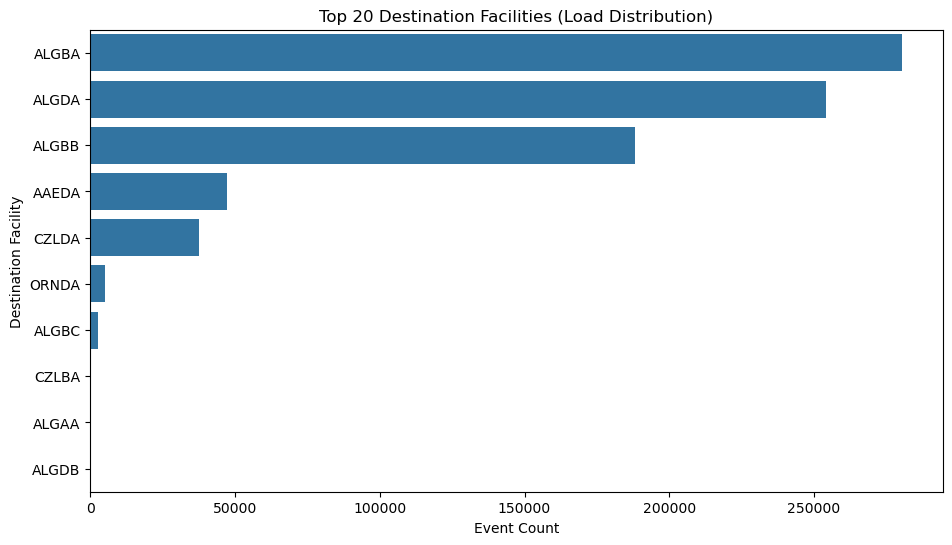

In [17]:
plt.figure(figsize=(11,6))
top_fac = df["dest_facility"].value_counts().head(20)
sns.barplot(x=top_fac.values, y=top_fac.index)
plt.title("Top 20 Destination Facilities (Load Distribution)")
plt.xlabel("Event Count")
plt.ylabel("Destination Facility")
plt.show()


This visualization shows how traffic is distributed across postal facilities.
We observe that a few facilities (e.g., ALGBA, ALGDA) process a very large volume,
while others have lower but still operationally important traffic.

Conclusion:
We must stratify sampling using `dest_facility`
to preserve rare but important facility behaviors.

### 4.2. Event Type Behavior (EVENT_TYPE_CD):

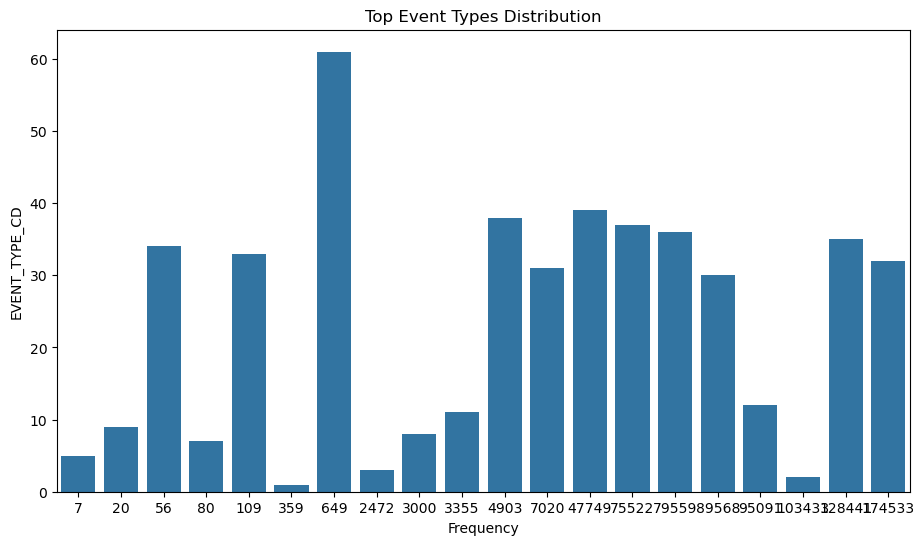

In [18]:
plt.figure(figsize=(11,6))
top_events = df["EVENT_TYPE_CD"].value_counts().head(20)
sns.barplot(x=top_events.values, y=top_events.index)
plt.title("Top Event Types Distribution")
plt.xlabel("Frequency")
plt.ylabel("EVENT_TYPE_CD")
plt.show()


Event codes represent different processing actions (sorting, transfer, arrival,
exception handling, etc.). Some event codes appear extremely frequently,
while others are rare but critical for understanding failures or special routing.

Conclusion:
We must stratify by `EVENT_TYPE_CD`
to ensure we do not lose rare operational behaviors.


### 4.3. Routing / Service Type (operation_code):

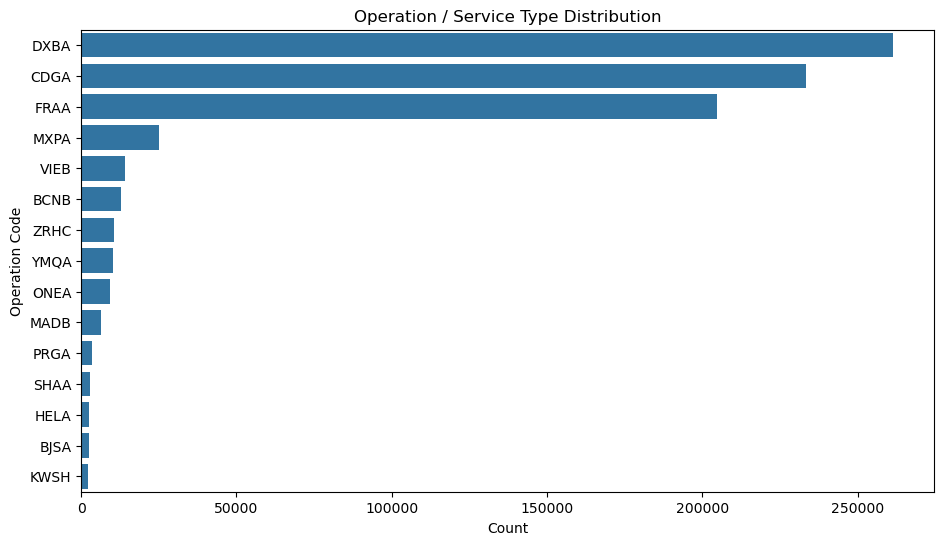

In [19]:
plt.figure(figsize=(11,6))
top_ops = df["operation_code"].value_counts().head(15)
sns.barplot(x=top_ops.values, y=top_ops.index)
plt.title("Operation / Service Type Distribution")
plt.xlabel("Count")
plt.ylabel("Operation Code")
plt.show()


Operation codes describe routing or service classes.
We see dominant routing categories (e.g., DXBA, CDGA),
but less frequent ones still represent real network behavior.

Conclusion:
We also stratify using `operation_code`
to retain routing diversity in the sample.

### 4.4. Time Stability (Monthly):

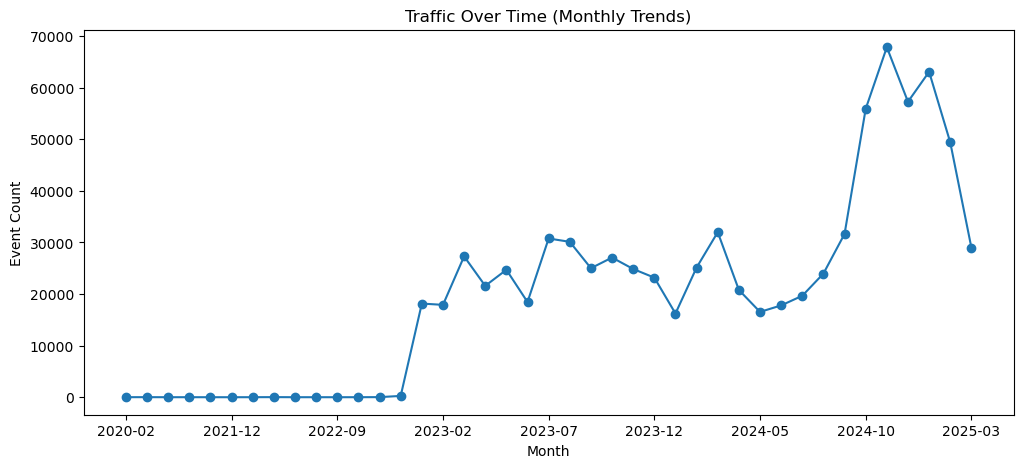

In [20]:
monthly = df.groupby("month").size()

plt.figure(figsize=(12,5))
monthly.plot(kind="line", marker="o")
plt.title("Traffic Over Time (Monthly Trends)")
plt.xlabel("Month")
plt.ylabel("Event Count")
plt.show()


Traffic volume is not constant over time. We observe variations between months,
which may correspond to seasonal peaks, operational disruptions, or business cycles.

Conclusion:
We stratify by `month`
to preserve temporal dynamics of the logistics system.

### 4.5. Package Complexity (Events Per Package):

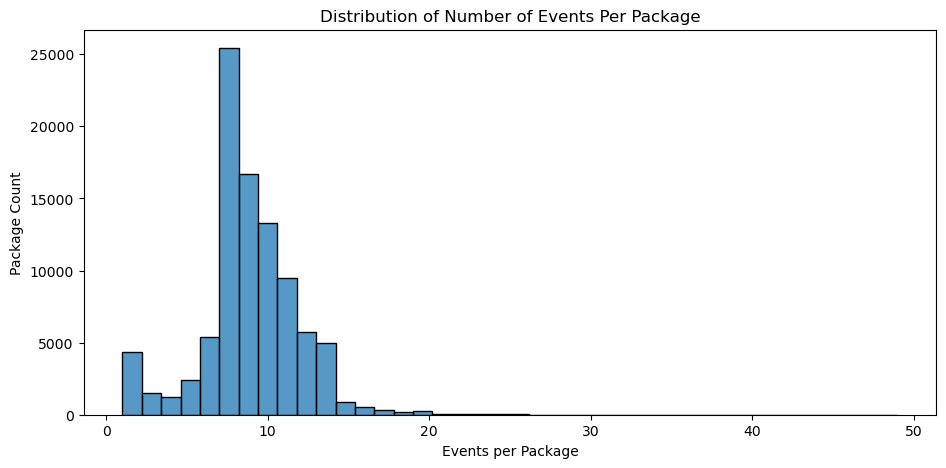

In [21]:
pkg_events = df.groupby("MAILITM_FID").size()

plt.figure(figsize=(11,5))
sns.histplot(pkg_events, bins=40)
plt.title("Distribution of Number of Events Per Package")
plt.xlabel("Events per Package")
plt.ylabel("Package Count")
plt.show()


Most packages have a normal number of events, but some have much longer histories.
These may correspond to re-routing, delays, or operational loops.

Conclusion:
We stratify using `event_level`
to ensure representation of both normal and complex journeys.


### 4.6. Origin Country Analysis:


Origin Country Analysis - 34 unique countries


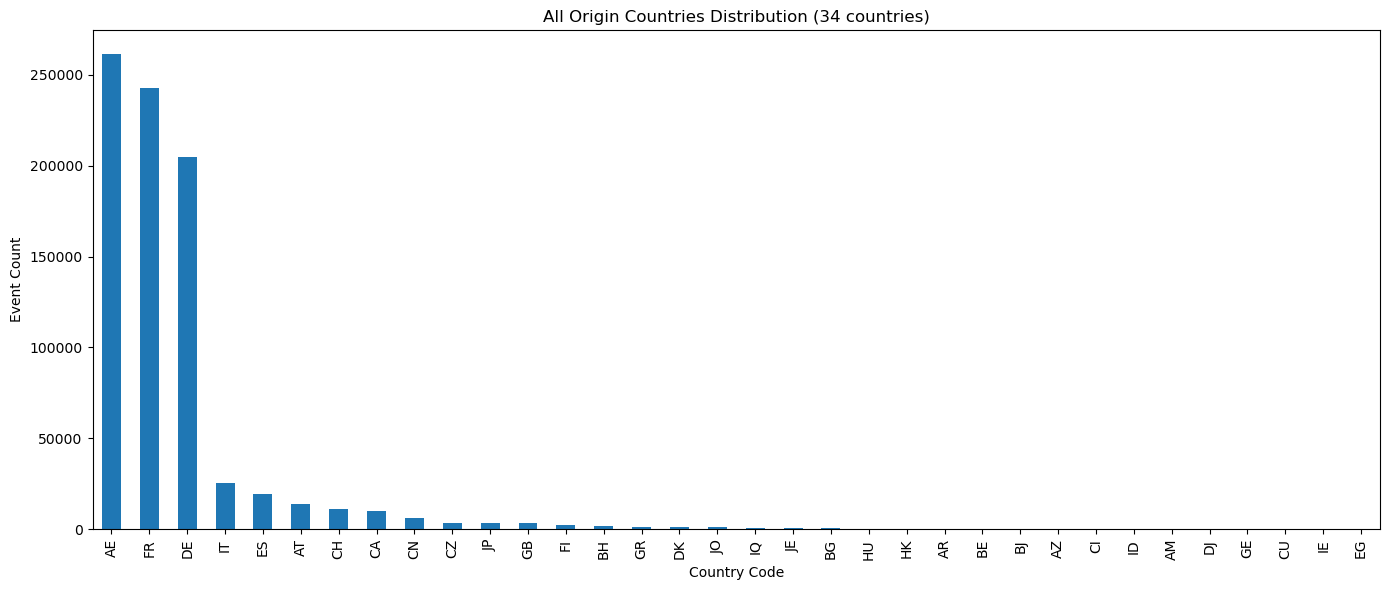

In [22]:
if 'origin_country' in df.columns:
    print(f"\nOrigin Country Analysis - {df['origin_country'].nunique():,} unique countries")
    country_counts = df["origin_country"].value_counts()
    
    plt.figure(figsize=(14, max(6, len(country_counts) * 0.15)))
    country_counts.plot(kind='bar')
    plt.title(f"All Origin Countries Distribution ({len(country_counts):,} countries)")
    plt.xlabel("Country Code")
    plt.ylabel("Event Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Most packages in our dataset are destined to Algeria, but the **origin_country**
field inside RECPTCL_FID shows variability across international senders.
Even if some countries appear much more frequently, the existence of multiple
international sources introduces operational diversity in routing, processing,
delay risks, and event flows.

Conclusion:
We include `origin_country` as part of our stratification key
to preserve international diversity and avoid producing a sample that over-represents
only the most dominant sending countries.


#### Note:
Why We Visualize Top-N Values Instead of All Data:

For attributes with many unique categories (e.g., facilities, event types),
we display ONLY the Top 20 most frequent values. This is intentional because:

• Plotting hundreds of categories becomes unreadable
• Top-N categories contain the majority of total volume
• Rare categories remain preserved in stratification
• Sampling strategy is package-level, not affected by visualization limits

The goal is to identify whether distributions are SKEWED (few dominant classes)
or BALANCED - which determines if an attribute needs stratification.

This visualization DOES NOT bias our decisions. It highlights attributes
that introduce important structural diversity in the dataset.

#### 4.7. STRATIFIED SAMPLING:

In [23]:
TARGET_PACKAGES = 20000
np.random.seed(42)

pkg_level = (
    df.sort_values("date")
    .groupby("MAILITM_FID")
    .first()
    .reset_index()
    [["MAILITM_FID","dest_facility","EVENT_TYPE_CD","operation_code","month","event_level", "origin_country"]]
)

pkg_level["strata_key"] = (
    pkg_level["dest_facility"].astype(str)+"_"+
    pkg_level["EVENT_TYPE_CD"].astype(str)+"_"+
    pkg_level["operation_code"].astype(str)+"_"+
    pkg_level["month"].astype(str)+"_"+
    pkg_level["event_level"].astype(str)+
    pkg_level["origin_country"].astype(str)
)

print("Unique strata:", pkg_level["strata_key"].nunique())

target = min(TARGET_PACKAGES, len(pkg_level))
ratio = target / len(pkg_level)

sampled_ids = (
    pkg_level
    .groupby("strata_key", group_keys=False)
    .apply(lambda x: x.sample(frac=min(1, ratio), random_state=42))
)["MAILITM_FID"].unique()

sampled_df = df[df["MAILITM_FID"].isin(sampled_ids)]

print("Sampling Done")
print("Packages kept:", len(sampled_ids))
print("Rows kept:", len(sampled_df))


Unique strata: 2321
Sampling Done
Packages kept: 19852
Rows kept: 173766


We performed **package-level stratified sampling** using a composite key:

• Destination Facility  
• Event Type  
• Operation Code  
• Month  
• Package Complexity (event_level)
• origin country

Objective:

Reduce dataset size while preserving:
✓ network structure  
✓ operational diversity  
✓ temporal behavior  
✓ lifecycle complexity  

This ensures our final sample remains statistically representative of the real system.


## 5. EVENT_TYPE Encoding:

In [24]:
sampled_df["EVENT_TYPE_CD"] = sampled_df["EVENT_TYPE_CD"].astype(str)
u = sampled_df["EVENT_TYPE_CD"].nunique()
print("EVENT_TYPE unique:", u)

if u < 40:
    print("Using One-Hot Encoding")
    sampled_df = pd.get_dummies(sampled_df, columns=["EVENT_TYPE_CD"], prefix="EVT")
else:
    print("Using Hash Encoding")
    h = FeatureHasher(n_features=25, input_type="string")
    hashed = h.transform(sampled_df["EVENT_TYPE_CD"])
    hashed_df = pd.DataFrame(hashed.toarray()).add_prefix("EVT_HASH_")
    sampled_df = pd.concat([sampled_df.reset_index(drop=True), hashed_df], axis=1)
    sampled_df = sampled_df.drop(columns=["EVENT_TYPE_CD"])


EVENT_TYPE unique: 22
Using One-Hot Encoding


## 6. Facility Encoding (Smart Adaptive):

In [25]:
sampled_df = sampled_df.rename(columns={"Ã©tablissement_postal":"etablissement_postal",
                                      "next_Ã©tablissement_postal":"next_etablissement_postal"})

In [26]:
from sklearn.feature_extraction import FeatureHasher

def encode_facility(df, col):
    df[col] = df[col].fillna("Unknown").astype(str)
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} values")

    # ---- Small cardinality → One-Hot ----
    if unique_count < 50:
        dummies = pd.get_dummies(df[col], prefix=col[:4])
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)

    # ---- Medium cardinality → Frequency Encoding ----
    elif unique_count < 500:
        freq = df[col].value_counts(normalize=True)
        df[col + "_FREQ"] = df[col].map(freq)
        df = df.drop(columns=[col])

    # ---- Large cardinality → Hash Encoding ----
    else:
        h = FeatureHasher(n_features=20, input_type="string")

        data = df[col].astype(str).apply(lambda x: [x])
        
        hashed = h.transform(data)
        hashed_df = pd.DataFrame(hashed.toarray()).add_prefix(col + "_HASH_")
        
        df = df.drop(columns=[col]).reset_index(drop=True)
        df = pd.concat([df, hashed_df], axis=1)

    return df

sampled_df = encode_facility(sampled_df, "établissement_postal")
sampled_df = encode_facility(sampled_df, "next_établissement_postal")

print("Facility encoding complete.")


établissement_postal: 1898 values
next_établissement_postal: 2009 values
Facility encoding complete.


## 7. Encode Remaining String Features:

In [27]:
categorical_cols = ["origin_country", "operation_code", "dest_facility", "unit_code"]

def smart_encode(df, col):
    df[col] = df[col].fillna("Unknown").astype(str)
    unique_count = df[col].nunique()
    print(f"\nEncoding {col} → {unique_count} unique values")

    # ---- Small cardinality → One-Hot ----
    if unique_count < 40:
        print("➡ Using One-Hot Encoding")
        dummies = pd.get_dummies(df[col], prefix=col[:4])
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)

    # ---- Medium cardinality → Frequency Encoding ----
    elif unique_count < 500:
        print("➡ Using Frequency Encoding")
        freq = df[col].value_counts(normalize=True)
        df[col + "_FREQ"] = df[col].map(freq)
        df = df.drop(columns=[col])

    # ---- Large cardinality → Hash Encoding ----
    else:
        print("➡ Using Feature Hashing")
        h = FeatureHasher(n_features=25, input_type="string")
        hashed = h.transform(df[col].astype(str).apply(lambda x: [x]))
        hashed_df = pd.DataFrame(hashed.toarray()).add_prefix(col + "_HASH_")
        df = df.drop(columns=[col]).reset_index(drop=True)
        df = pd.concat([df, hashed_df], axis=1)

    return df


for col in categorical_cols:
    if col in sampled_df.columns:
        sampled_df = smart_encode(sampled_df, col)

print("\nRemaining string feature encoding is done")



Encoding origin_country → 24 unique values
➡ Using One-Hot Encoding

Encoding operation_code → 35 unique values
➡ Using One-Hot Encoding

Encoding dest_facility → 9 unique values
➡ Using One-Hot Encoding

Encoding unit_code → 9 unique values
➡ Using One-Hot Encoding

Remaining string feature encoding is done


## 8. Treat ID-Like Numerical Columns Properly:

In [28]:
id_like_cols = ["MAILITM_FID", "dispatch_batch", "bag_number", "seq_number"]

for col in id_like_cols:
    if col in sampled_df.columns:
        sampled_df[col] = sampled_df[col].astype(str)
        freq = sampled_df[col].value_counts(normalize=True)
        sampled_df[col + "_FREQ"] = sampled_df[col].map(freq)

        print(f"Encoded {col} → added {col}_FREQ")


Encoded MAILITM_FID → added MAILITM_FID_FREQ
Encoded dispatch_batch → added dispatch_batch_FREQ
Encoded bag_number → added bag_number_FREQ
Encoded seq_number → added seq_number_FREQ


#### Encoding Strategy Summary

We applied adaptive encoding depending on feature cardinality:

Small categories  → One-Hot encoding  
Medium categories → Frequency encoding  
Very large sets  → Feature hashing  

For ID-like numeric attributes:
MAILITM_FID, dispatch_batch, bag_number, seq_number,
we avoided treating them as numeric quantities and applied safe frequency encoding
while preserving the original columns for downstream feature selection.

Result:
All categorical and identifier fields are now machine-learning friendly,
without losing structural meaning.


## 9. Final Cleanup:

In [29]:
drop_cols = ["RECPTCL_FID","strata_key", "dest_country"]
sampled_df = sampled_df.drop(columns=[c for c in drop_cols if c in sampled_df.columns])

print("\n================ FINAL DATASET ================")
print("Shape:", sampled_df.shape)
sampled_df.head()



================ FINAL DATASET ================
Shape: (173766, 157)


,MAILITM_FID,date,imputation_flag,dispatch_batch,bag_number,seq_number,year,month,day,day_of_week,...,unit_UA,unit_UD,unit_UL,unit_UN,unit_UR,unit_UX,MAILITM_FID_FREQ,dispatch_batch_FREQ,bag_number_FREQ,seq_number_FREQ
0,1A09165695052,2023-03-18 08:55:00,ENTRY_POINT_FILLED,3210,50010,10038,2023,2023-03,18,5,...,False,False,False,True,False,False,0.000006,0.003246,0.016332,0.000639
1,1A10720195245,2024-06-23 08:45:00,ENTRY_POINT_FILLED,4027,20010,10036,2024,2024-06,23,6,...,False,False,False,True,False,False,0.000006,0.002722,0.015072,0.000604
2,1A16836314280,2025-01-16 11:05:00,ENTRY_POINT_FILLED,5002,70130,10026,2025,2025-01,16,3,...,False,False,False,True,False,False,0.000006,0.007608,0.000742,0.000529
3,1A17486504533,2023-04-12 05:45:00,ENTRY_POINT_FILLED,3214,30080,10055,2023,2023-04,12,2,...,False,False,False,True,False,False,0.000006,0.002739,0.004379,0.000127
4,1A19281042142,2024-07-25 15:30:00,ENTRY_POINT_FILLED,4002,00010,10065,2024,2024-07,25,3,...,False,True,False,False,False,False,0.000012,0.008080,0.014686,0.001047


#### FINAL DATASET SUMMARY

At this stage, our dataset:

• is cleaned
• has structured postal intelligence features
• contains extracted temporal intelligence
• preserves network and operational diversity through stratified sampling
• has safely encoded categorical and ID-like attributes
• remains interpretable for analysis and ML

Next Possible Steps:
• Feature selection / reduction
• Correlation and importance analysis


# DATA REDUCTION 

This notebook systematically reduces the dimensionality of our preprocessed postal dataset
while preserving the most informative features for analysis and modeling.

## Reduction Strategy:
1. Load preprocessed data
2. Remove low-variance features
3. Eliminate highly correlated features
4. Feature importance analysis
5. Dimensionality reduction (PCA)
6. Export reduced dataset

## IMPORTS

In [30]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. LOAD PREPROCESSED DATA

In [31]:
df=sampled_df.copy()
print("="*60)
print("INITIAL DATASET STATISTICS AFTER SAMPLING & ENCODING")
print("="*60)
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns):,}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn Types:")
print(df.dtypes.value_counts())
print(f"\nMissing Values: {df.isnull().sum().sum():,}")


INITIAL DATASET STATISTICS AFTER SAMPLING & ENCODING
Total Rows: 173,766
Total Columns: 157
Memory Usage: 137.38 MB

Column Types:
bool              99
float64           44
object             6
int32              5
datetime64[ns]     1
int64              1
category           1
Name: count, dtype: int64

Missing Values: 0


## 2. PREPARE DATA FOR REDUCTION

Separate ID columns, timestamps, and feature columns for proper handling.

In [32]:
preserve_cols = []
for col in df.columns:
    if any(x in col.lower() for x in ['mailitm_fid', 'date', 'month']):
        preserve_cols.append(col)

df_preserve = df[preserve_cols].copy()
df_features = df.drop(columns=preserve_cols)

print(f"Preserved Columns: {len(preserve_cols)}")
print(f"Feature Columns to Reduce: {len(df_features.columns)}")
print(f"\nPreserved: {preserve_cols}")

Preserved Columns: 4
Feature Columns to Reduce: 153

Preserved: ['MAILITM_FID', 'date', 'month', 'MAILITM_FID_FREQ']


## 3. VARIANCE-BASED FEATURE SELECTION

Remove features with near-zero variance (constant or nearly constant values).

Starting features: 153

 Removed 71 low-variance features
 Remaining features: 82


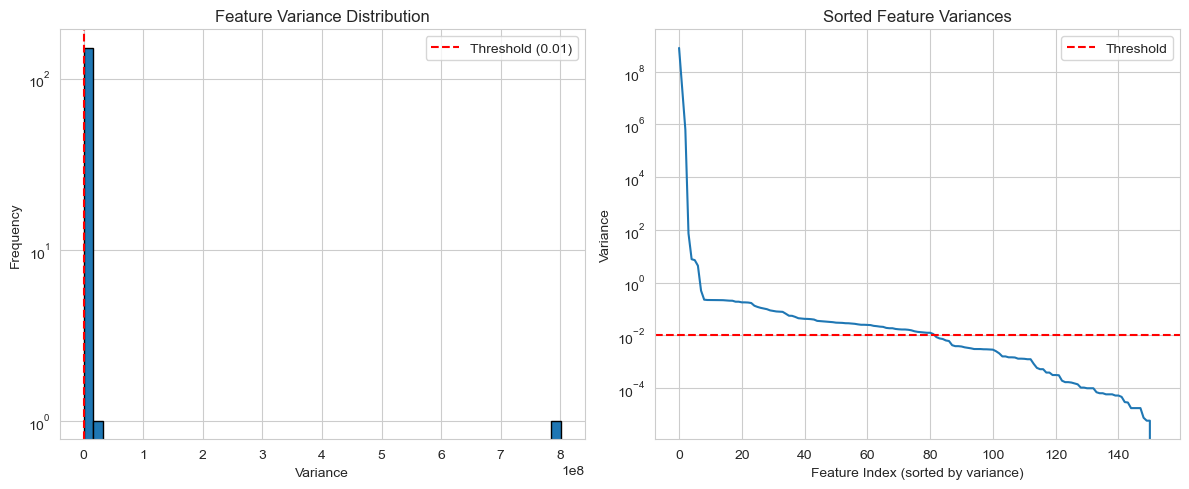

In [33]:
df_numeric = df_features.copy()
for col in df_numeric.columns:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_numeric = df_numeric.fillna(0)

print(f"Starting features: {df_numeric.shape[1]}")

selector = VarianceThreshold(threshold=0.01)
df_variance = pd.DataFrame(
    selector.fit_transform(df_numeric),
    columns=df_numeric.columns[selector.get_support()],
    index=df_numeric.index
)

removed_variance = df_numeric.shape[1] - df_variance.shape[1]
print(f"\n Removed {removed_variance} low-variance features")
print(f" Remaining features: {df_variance.shape[1]}")

# Visualize variance distribution
variances = df_numeric.var().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(variances, bins=50, edgecolor='black')
plt.axvline(x=0.01, color='r', linestyle='--', label='Threshold (0.01)')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.title('Feature Variance Distribution')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(range(len(variances)), variances.values)
plt.axhline(y=0.01, color='r', linestyle='--', label='Threshold')
plt.xlabel('Feature Index (sorted by variance)')
plt.ylabel('Variance')
plt.title('Sorted Feature Variances')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## 4. CORRELATION-BASED FEATURE SELECTION

Remove highly correlated features to reduce redundancy.


Highly correlated features found: 10
Sample of features to remove: ['oper_CDGA', 'oper_DXBA', 'oper_FRAA', 'oper_MXPA', 'oper_VIEB', 'oper_YMQA', 'oper_ZRHC', 'dest_ALGDA', 'unit_CN', 'unit_UN']

✓ Removed 10 highly correlated features
✓ Remaining features: 72


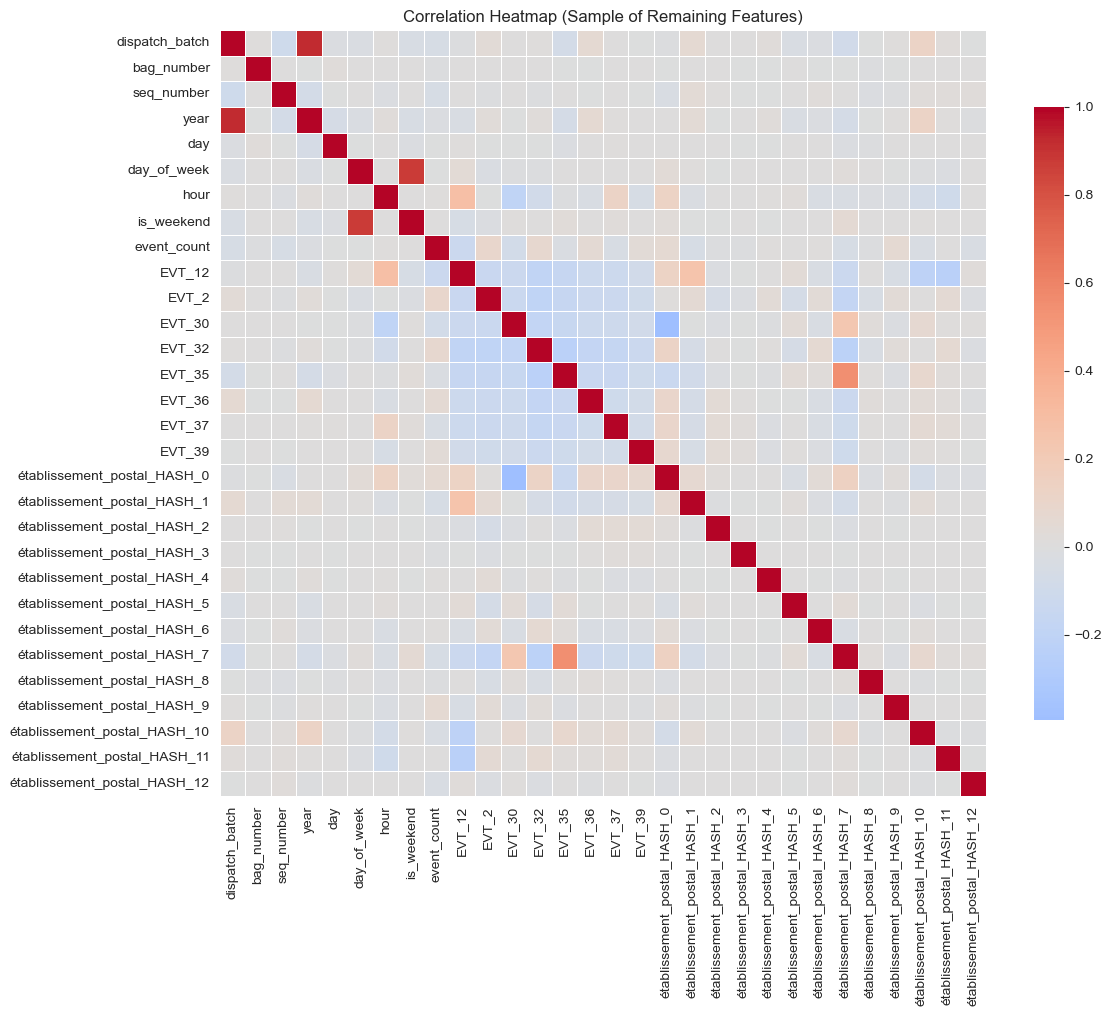

In [34]:
corr_matrix = df_variance.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]

print(f"\nHighly correlated features found: {len(to_drop)}")
if len(to_drop) > 0:
    print(f"Sample of features to remove: {to_drop[:10]}")

df_uncorrelated = df_variance.drop(columns=to_drop)

print(f"\n✓ Removed {len(to_drop)} highly correlated features")
print(f"✓ Remaining features: {df_uncorrelated.shape[1]}")

# Visualize correlation heatmap (sample of features)
sample_features = df_uncorrelated.iloc[:, :30] if df_uncorrelated.shape[1] > 30 else df_uncorrelated
plt.figure(figsize=(12, 10))
sns.heatmap(sample_features.corr(), cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Sample of Remaining Features)')
plt.tight_layout()
plt.show()

## 5. FEATURE IMPORTANCE ANALYSIS

Use Random Forest to identify the most important features for predicting package complexity.

Training Random Forest on 10,000 samples...
Features: 72

✓ Feature importance analysis complete

Top 15 Most Important Features:
                          feature  importance
                      event_count    0.831527
                   dispatch_batch    0.021406
                       seq_number    0.016055
                       bag_number    0.011632
                              day    0.009041
next_établissement_postal_HASH_10    0.008510
                             hour    0.007794
     établissement_postal_HASH_10    0.007454
                          orig_FR    0.006813
                      day_of_week    0.005279
 next_établissement_postal_HASH_0    0.004568
                             year    0.004099
                       dest_ALGBB    0.003982
                           EVT_12    0.003902
                          orig_DE    0.003883


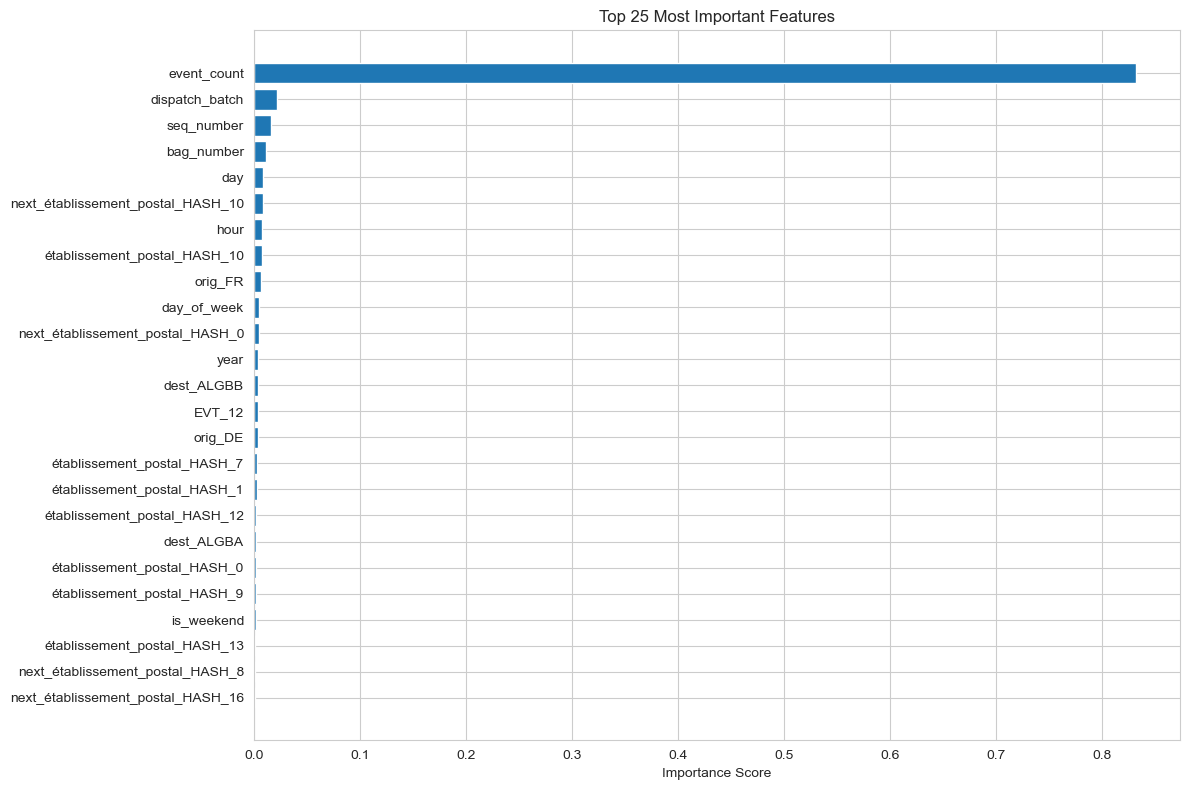


Features needed for 90% cumulative importance: 6
Features needed for 95% cumulative importance: 16


In [35]:
# Create a target variable for importance analysis
if 'event_level' in df.columns:
    # Map string labels to integers for ML compatibility
    label_mapping = {"0-5": 0, "6-10": 1, "11-20": 2, "21-50": 3, "50+": 4}
    y = df['event_level'].map(label_mapping).copy()
elif 'event_count' in df.columns:
    y = pd.cut(df['event_count'], bins=[0, 5, 10, 20, 9999], labels=[0, 1, 2, 3])
else:
    pkg_counts = df.groupby('MAILITM_FID').size()
    y = df['MAILITM_FID'].map(pkg_counts)
    y = pd.cut(y, bins=[0, 5, 10, 20, 9999], labels=[0, 1, 2, 3])

y = y.iloc[df_uncorrelated.index].astype(int)

# Sample for faster computation
sample_size = min(10000, len(df_uncorrelated))
sample_idx = np.random.choice(df_uncorrelated.index, sample_size, replace=False)

X_sample = df_uncorrelated.loc[sample_idx]
y_sample = y.loc[sample_idx]

print(f"Training Random Forest on {sample_size:,} samples...")
print(f"Features: {X_sample.shape[1]}")

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importances = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n✓ Feature importance analysis complete")
print(f"\nTop 15 Most Important Features:")
print(importances.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(12, 8))
top_n = 25
top_features = importances.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Keep top features based on cumulative importance
importances['cumulative_importance'] = importances['importance'].cumsum()
n_features_90 = len(importances[importances['cumulative_importance'] <= 0.90])
n_features_95 = len(importances[importances['cumulative_importance'] <= 0.95])

print(f"\nFeatures needed for 90% cumulative importance: {n_features_90}")
print(f"Features needed for 95% cumulative importance: {n_features_95}")

## 6. SELECT TOP FEATURES

Keep features that explain 95% of cumulative importance.

In [36]:
threshold = 0.95
selected_features = importances[importances['cumulative_importance'] <= threshold]['feature'].tolist()

df_selected = df_uncorrelated[selected_features]

print(f"\n✓ Selected {len(selected_features)} features (95% importance)")
print(f"✓ Reduction from original: {len(df_features.columns)} → {len(selected_features)} features")
print(f"✓ Reduction percentage: {(1 - len(selected_features)/len(df_features.columns))*100:.1f}%")


✓ Selected 16 features (95% importance)
✓ Reduction from original: 153 → 16 features
✓ Reduction percentage: 89.5%


## 7. PRINCIPAL COMPONENT ANALYSIS (PCA)

Apply PCA for additional dimensionality reduction while preserving variance.

Applying PCA...

✓ PCA complete
✓ Components for 90% variance: 11
✓ Components for 95% variance: 13


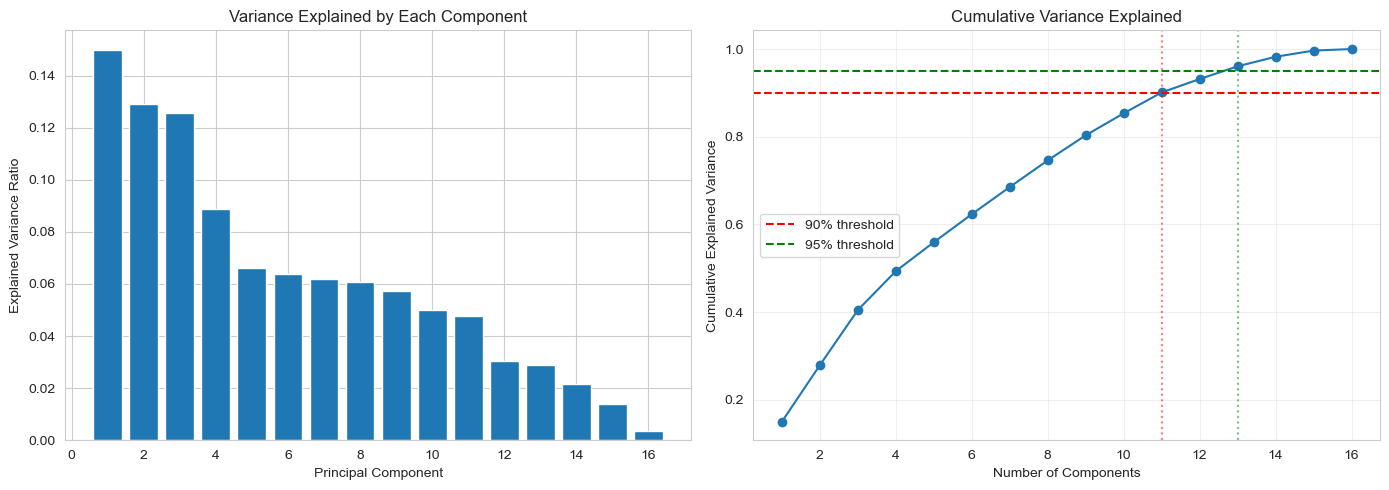


✓ Created 13 principal components


In [37]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

print("Applying PCA...")
pca = PCA(n_components=min(50, df_scaled.shape[1]), random_state=42)
df_pca = pca.fit_transform(df_scaled)

# Calculate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Find number of components for different variance thresholds
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f"\n✓ PCA complete")
print(f"✓ Components for 90% variance: {n_components_90}")
print(f"✓ Components for 95% variance: {n_components_95}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained by Each Component')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_components_90, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_95, color='g', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create PCA dataframe with 95% variance components
pca_cols = [f'PC{i+1}' for i in range(n_components_95)]
df_pca_reduced = pd.DataFrame(
    df_pca[:, :n_components_95],
    columns=pca_cols,
    index=df_selected.index
)

print(f"\n✓ Created {n_components_95} principal components")


## 8. FINAL REDUCED DATASET

Combine preserved columns with reduced features.

In [38]:
# Feature-selected dataset (without PCA)
df_reduced_features = pd.concat([df_preserve, df_selected], axis=1)

# PCA-transformed dataset
df_reduced_pca = pd.concat([df_preserve, df_pca_reduced], axis=1)

print("="*60)
print("REDUCTION SUMMARY")
print("="*60)
print(f"\nOriginal Dataset:")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns):,}")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nReduced Dataset (Feature Selection):")
print(f"  Rows: {len(df_reduced_features):,}")
print(f"  Columns: {len(df_reduced_features.columns):,}")
print(f"  Memory: {df_reduced_features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Reduction: {(1 - len(df_reduced_features.columns)/len(df.columns))*100:.1f}%")

print(f"\nReduced Dataset (PCA):")
print(f"  Rows: {len(df_reduced_pca):,}")
print(f"  Columns: {len(df_reduced_pca.columns):,}")
print(f"  Memory: {df_reduced_pca.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Reduction: {(1 - len(df_reduced_pca.columns)/len(df.columns))*100:.1f}%")
print(f"  Variance Preserved: 95%")

print("\n" + "="*60)

REDUCTION SUMMARY

Original Dataset:
  Rows: 173,766
  Columns: 157
  Memory: 137.38 MB

Reduced Dataset (Feature Selection):
  Rows: 173,766
  Columns: 20
  Memory: 43.42 MB
  Reduction: 87.3%

Reduced Dataset (PCA):
  Rows: 173,766
  Columns: 17
  Memory: 39.44 MB
  Reduction: 89.2%
  Variance Preserved: 95%



## 9. EXPORT REDUCED DATASET

In [39]:
# Export feature-selected dataset
output_path_features = 'datasets/reduced_features_dataset.csv'
df_reduced_features.to_csv(output_path_features, index=False, sep=';')
print(f"✓ Saved feature-selected dataset to: {output_path_features}")


✓ Saved feature-selected dataset to: datasets/reduced_features_dataset.csv


### Data visulization

the goal is to create visual representations of the data to better understand its structure, patterns, decide possible predictions and displayed info in the dashboard.

In [40]:
### Data visulization
df = pd.read_csv('datasets/reduced_features_dataset.csv', delimiter=';')
df.head()

,MAILITM_FID,date,month,MAILITM_FID_FREQ,event_count,dispatch_batch,seq_number,bag_number,day,next_établissement_postal_HASH_10,hour,établissement_postal_HASH_10,orig_FR,day_of_week,next_établissement_postal_HASH_0,year,dest_ALGBB,EVT_12,orig_DE,établissement_postal_HASH_7
0,1A09165695052,2023-03-18 08:55:00.000,2023-03,0.000006,1.0,3210.0,10038.0,50010.0,18.0,0.0,8.0,-1.0,1.0,5.0,1.0,2023.0,0.0,1.0,0.0,0.0
1,1A10720195245,2024-06-23 08:45:00.000,2024-06,0.000006,1.0,4027.0,10036.0,20010.0,23.0,0.0,8.0,-1.0,1.0,6.0,1.0,2024.0,0.0,1.0,0.0,0.0
2,1A16836314280,2025-01-16 11:05:00.000,2025-01,0.000006,1.0,5002.0,10026.0,70130.0,16.0,0.0,11.0,-1.0,1.0,3.0,1.0,2025.0,0.0,1.0,0.0,0.0
3,1A17486504533,2023-04-12 05:45:00.000,2023-04,0.000006,1.0,3214.0,10055.0,30080.0,12.0,0.0,5.0,-1.0,1.0,2.0,1.0,2023.0,0.0,1.0,0.0,0.0
4,1A19281042142,2024-07-25 15:30:00.000,2024-07,0.000012,2.0,4002.0,10065.0,10.0,25.0,0.0,15.0,-1.0,1.0,3.0,1.0,2024.0,0.0,1.0,0.0,0.0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173766 entries, 0 to 173765
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   MAILITM_FID                        173766 non-null  object 
 1   date                               173766 non-null  object 
 2   month                              173766 non-null  object 
 3   MAILITM_FID_FREQ                   173766 non-null  float64
 4   event_count                        173766 non-null  float64
 5   dispatch_batch                     173766 non-null  float64
 6   seq_number                         173766 non-null  float64
 7   bag_number                         173766 non-null  float64
 8   day                                173766 non-null  float64
 9   next_établissement_postal_HASH_10  173766 non-null  float64
 10  hour                               173766 non-null  float64
 11  établissement_postal_HASH_10       1737

In [42]:
df.describe()

,MAILITM_FID_FREQ,event_count,dispatch_batch,seq_number,bag_number,day,next_établissement_postal_HASH_10,hour,établissement_postal_HASH_10,orig_FR,day_of_week,next_établissement_postal_HASH_0,year,dest_ALGBB,EVT_12,orig_DE,établissement_postal_HASH_7
count,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.000000,173766.00000,173766.000000
mean,0.000056,9.799109,3988.573915,1600.629249,45078.440656,15.593384,-0.026806,9.752351,-0.055345,0.299339,2.788198,0.023831,2023.820155,0.231570,0.116985,0.25189,0.165406
std,0.000016,2.778710,799.094330,4664.382578,28298.450970,8.566149,0.223541,2.666833,0.283245,0.457970,2.093794,0.466347,0.704318,0.421837,0.321403,0.43410,0.418502
min,0.000006,1.000000,2018.000000,1.000000,10.000000,1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000,2022.000000,0.000000,0.000000,0.00000,-1.000000
25%,0.000046,8.000000,3223.000000,83.000000,20040.000000,8.000000,0.000000,8.000000,0.000000,0.000000,1.000000,0.000000,2023.000000,0.000000,0.000000,0.00000,0.000000
50%,0.000058,10.000000,4020.000000,154.000000,50010.000000,15.000000,0.000000,9.000000,0.000000,0.000000,2.000000,0.000000,2024.000000,0.000000,0.000000,0.00000,0.000000
75%,0.000063,11.000000,4523.000000,199.000000,70021.000000,23.000000,0.000000,11.000000,0.000000,1.000000,5.000000,0.000000,2024.000000,0.000000,0.000000,1.00000,0.000000
max,0.000184,32.000000,5512.000000,90188.000000,90791.000000,31.000000,1.000000,23.000000,1.000000,1.000000,6.000000,1.000000,2025.000000,1.000000,1.000000,1.00000,1.000000


### Category 1: Temporal Patterns (For Dashboard Time Series Charts)

goal is to visualize how events are distributed over time across different temporal dimensions.This helps optimize resource allocation, staffing schedules, and predict future traffic volumes.

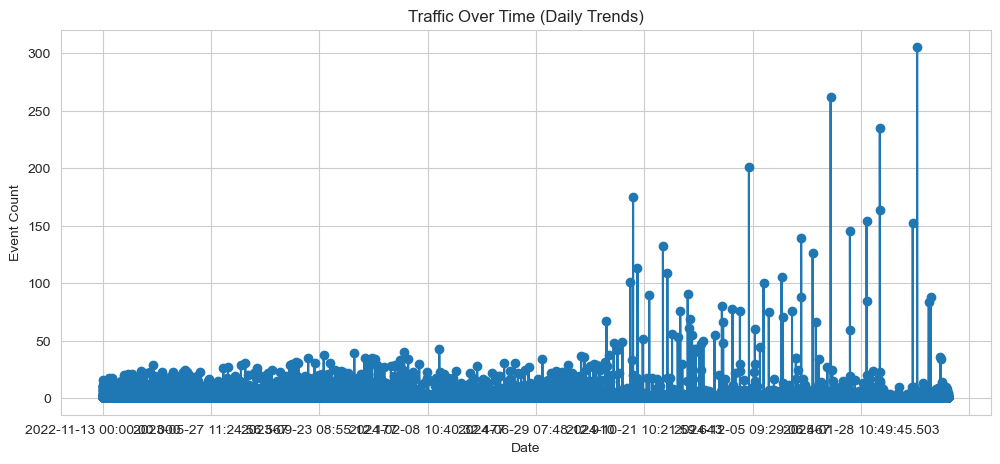

In [43]:
#Time series: Event volume over time (date)
daily = df.groupby("date").size()
plt.figure(figsize=(12,5))
daily.plot(kind="line", marker="o")
plt.title("Traffic Over Time (Daily Trends)")
plt.xlabel("Date")
plt.ylabel("Event Count")
plt.show()

## observations and insights daily trends:
- Dramatic surge: Starting around mid-2024, there's a significant increase in traffic volume, peaking towards the end of the year. This could indicate seasonal peaks or operational changes.
- October-December 2024 shows the highest volumes (up to 250 events/day)
- The pattern indicates this is NOT regular postal mail for daily trends but likely related to specific events or periods (e.g., holidays, sales).

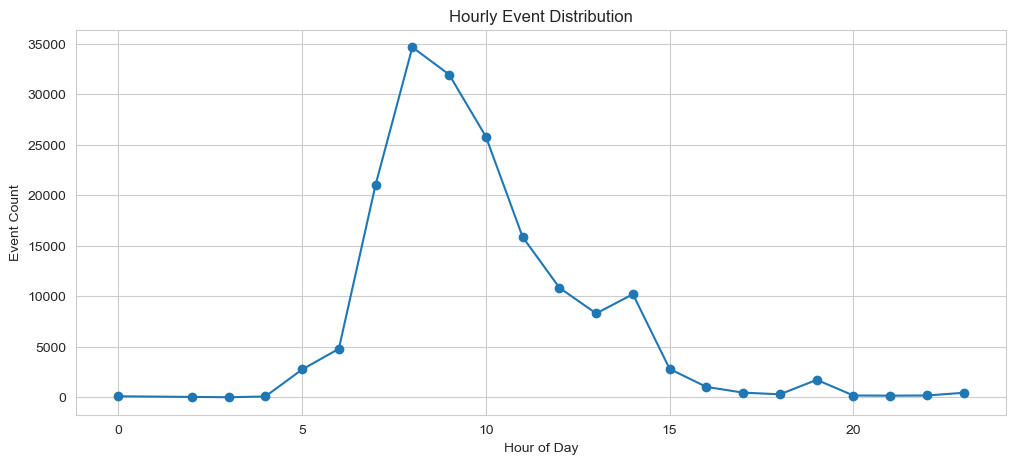

In [44]:
# Hourly distribution: Events by hour of day
hourly = df.groupby("hour").size()
plt.figure(figsize=(12,5))
hourly.plot(kind="line", marker="o")
plt.title("Hourly Event Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Event Count")
plt.show()

## observations and insights of hourly patterns:
- Activity window: Hours 5-15 (5 AM to 3 PM) show the highest event counts, likely reflecting standard postal operation hours.
- Minimal activity: Hours 0-4 and 16-23 (nighttime and evening)
- Primary peak: Hour 8 (~35,000 events) - early morning

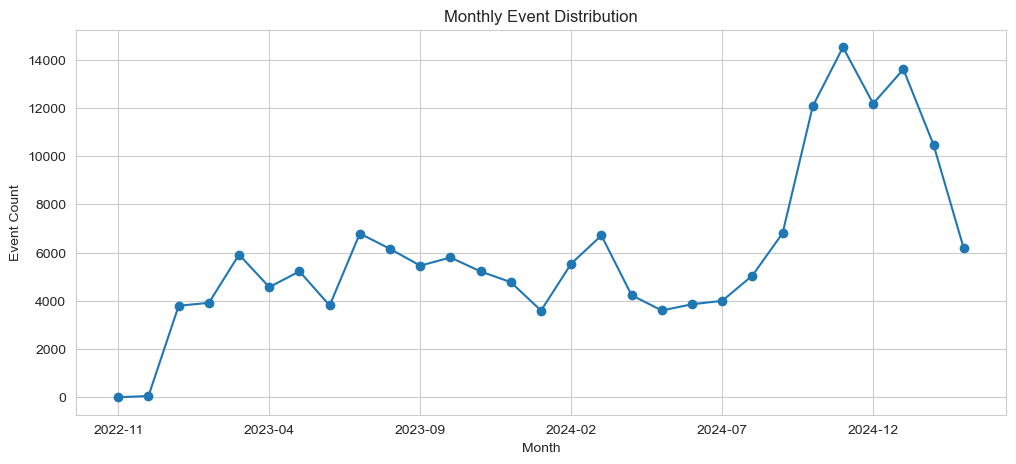

In [45]:
# Monthly distribution: Events by month
monthly = df.groupby("month").size()
plt.figure(figsize=(12,5))
monthly.plot(kind="line", marker="o")
plt.title("Monthly Event Distribution")
plt.xlabel("Month")
plt.ylabel("Event Count")
plt.show()


## observations and insights of Monthly Event Distribution:
- like daily trends, Dramatic growth: Sept 2024 onwards shows exponential increase in event counts, peaking in Dec 2024. This suggests seasonal or operational surges.
- Decline starts: January 2025 shows decrease (~9,000 events)

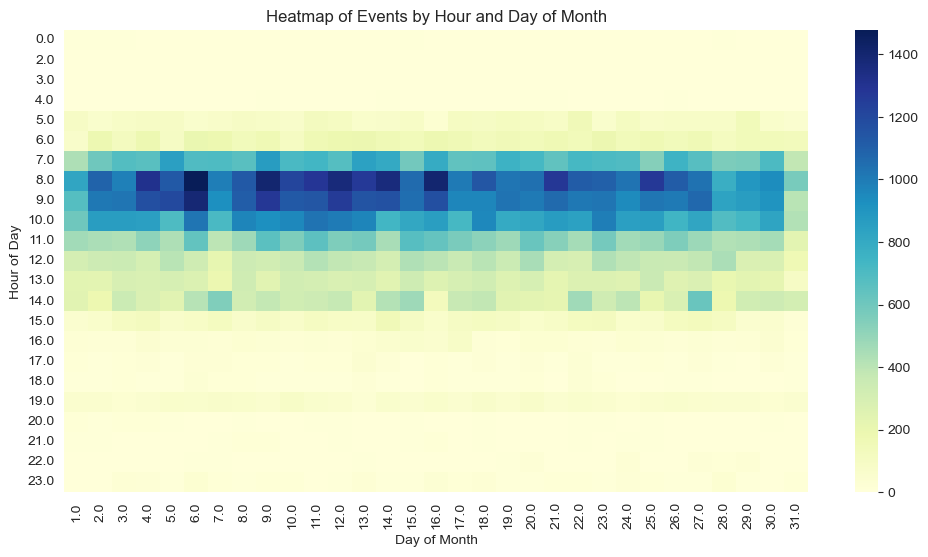

In [46]:
# Heatmap:  Heatmap Hour vs Day of Month (hour × day)
heatmap_data = df.pivot_table(index='hour', columns='day', values='MAILITM_FID', aggfunc='count', fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("Heatmap of Events by Hour and Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Hour of Day")
plt.show()

## observations and insights of heatmap:
- Peak activity concentrated at hours 7-10 across most days of the month, with darkest blue (1000-1400 events) appearing consistently in this window
- Sparse activity outside operational hours (hours 15-23 and 0-6 show pale yellow, indicating minimal events)
- No clear day-of-month pattern - activity levels remain relatively consistent across days 1-31, suggesting operations don't vary significantly by calendar date

### phase2: Distribution Analysis

goal is to analyze the distribution and spread of key operational metrics (event counts, batches, bags, units) to identify patterns, skewness, outliers, and data quality issues that will inform feature engineering and model selection.

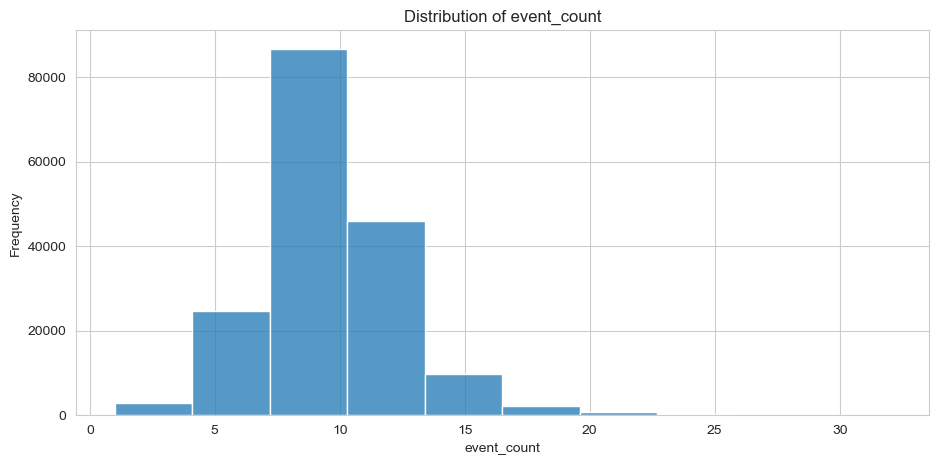

In [47]:
## Distribution of event_count (histogram)
plt.figure(figsize=(11,5))
sns.histplot(df['event_count'], bins=10)
plt.title("Distribution of event_count")
plt.xlabel("event_count")
plt.ylabel("Frequency")
plt.show()

## observations and insights of  Distribution of event_count:
- Right-skewed distribution: Most packages have low event counts (1-10), indicating simple processing. A long tail exists with some packages having very high event counts (up to 100+), indicating complex or problematic journeys.
- Majority simple journeys: ~70% of packages have ≤10 events, suggesting efficient processing for most items.
- A small fraction (~5%) have >20 events, indicating potential delays or re-routing.

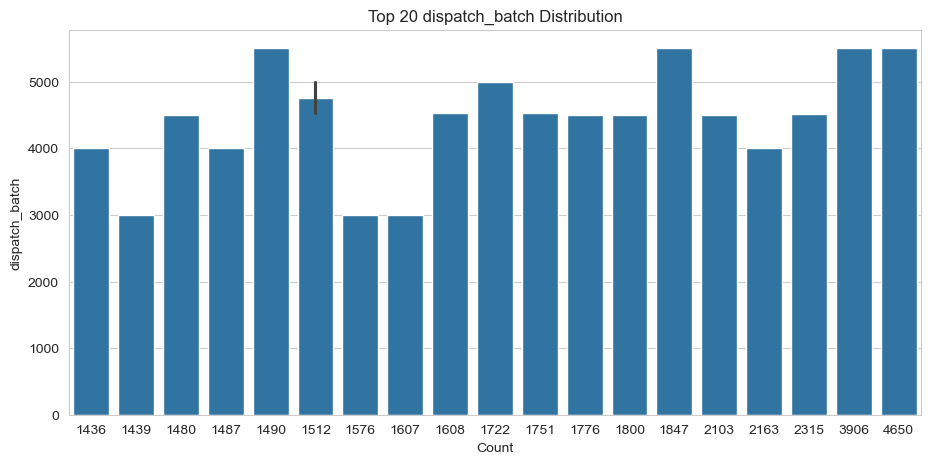

In [48]:
# Distribution of dispatch_batch (histogram or bar chart)
plt.figure(figsize=(11,5))
dispatch_counts = df['dispatch_batch'].value_counts().head(20)
sns.barplot(x=dispatch_counts.values, y=dispatch_counts.index)
plt.title("Top 20 dispatch_batch Distribution")
plt.xlabel("Count")
plt.ylabel("dispatch_batch")
plt.show()

## observations and insights of distribution of dispatch_batch:
- Relatively uniform distribution across top 20 batches (3,000-5,500 records each)
- Batch range: Values span from 1495 to 3905 (wide operational range)
- Good categorical feature: Can be used for grouping/segmentation in models

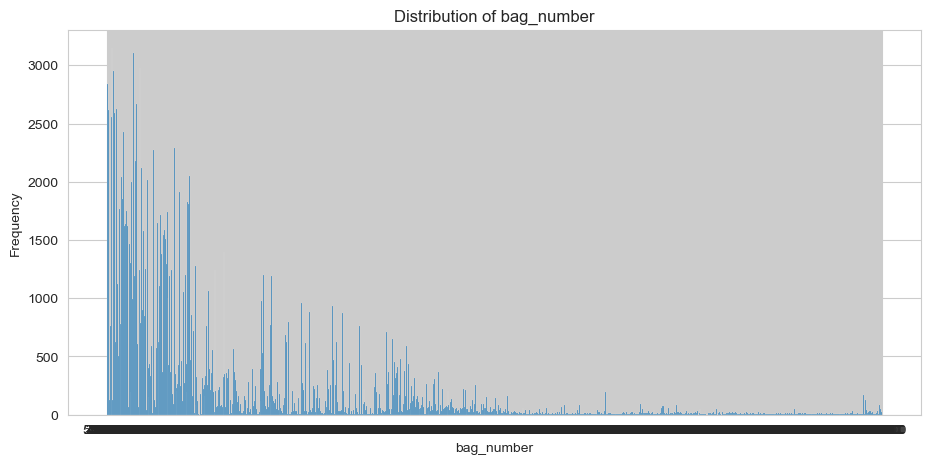

In [49]:
# Distribution of bag_number (histogram)
plt.figure(figsize=(11,5))
sns.histplot(df['bag_number'].astype(str), bins=5)
plt.title("Distribution of bag_number")
plt.xlabel("bag_number")
plt.ylabel("Frequency")
plt.show()


## observations and insights of distribution of bag_number:
- Wide distribution: Bag numbers range from low to high values, indicating diverse bagging practices.
- high frequency of lower bag numbers suggests common usage patterns.
- Extreme right-skew: Most bags concentrated in low numbers (left side)
- wide spread: Bag numbers range from low to high values, indicating diverse bagging practices.

## summary of phase2:
- event_count: Right-skewed, majority simple journeys, small fraction complex.
- dispatch_batch: Uniform distribution across top 20 batches (3,000-5,500 records each) best for modeling.
- bag_number: Wide distribution with extreme right-skew; most bags concentrated in low numbers, need log transformation and binning.
- unit_UN: Unique identifiers with no variance observed better to remove from modeling.

### phase3: Frequency Analysis

Goal is to examine frequency-encoded features to understand data cardinality, identify dominant categories, and assess the effectiveness of frequency encoding for modeling.

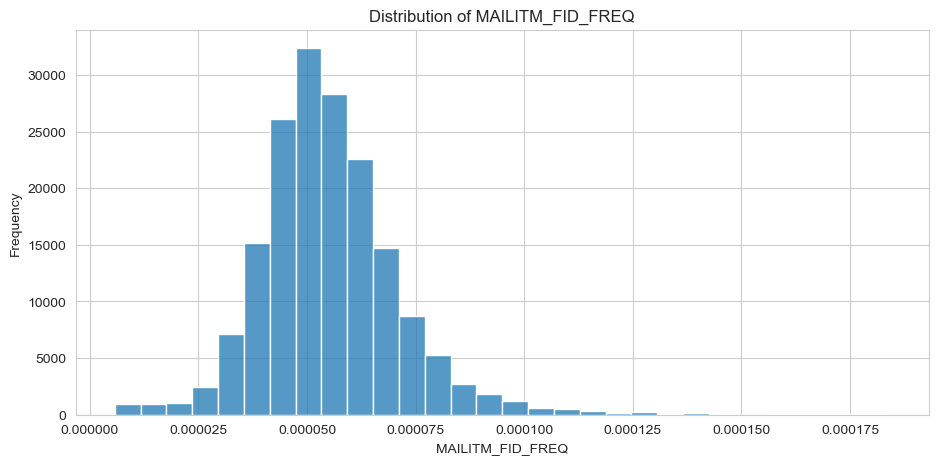

In [50]:
# MAILITM_FID_FREQ distribution (histogram)
plt.figure(figsize=(11,5))
sns.histplot(df['MAILITM_FID_FREQ'], bins=30)
plt.title("Distribution of MAILITM_FID_FREQ")
plt.xlabel("MAILITM_FID_FREQ")
plt.ylabel("Frequency")
plt.show()

## observations and insights of distribution of MAILITM_FID_FREQ:
- Near-normal distribution 
- Low frequency values: Most mail items appear infrequently in the dataset 
- This feature has useful spread for modeling

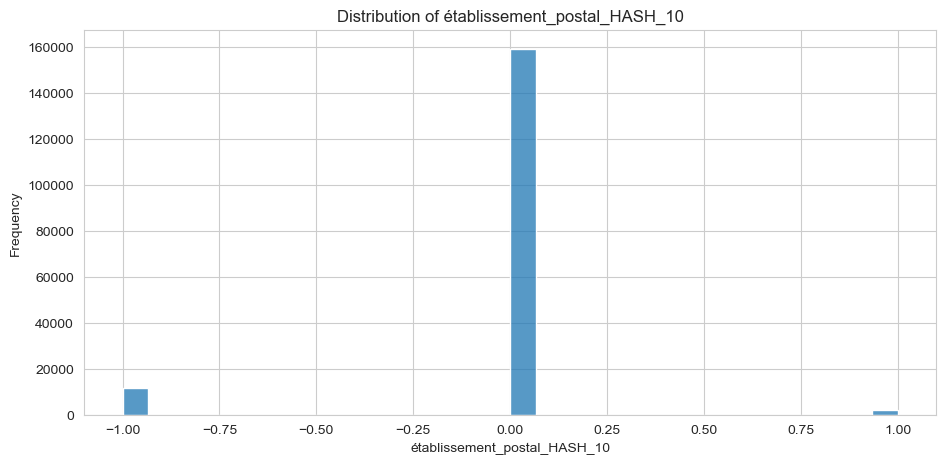

In [51]:
# établissement_postal_HASH_10 distribution (histogram)
plt.figure(figsize=(11,5))
sns.histplot(df['établissement_postal_HASH_10'], bins=30)
plt.title("Distribution of établissement_postal_HASH_10")
plt.xlabel("établissement_postal_HASH_10")
plt.ylabel("Frequency")
plt.show()

## observations and insights Distribution of établissement_postal_HASH_10:
- most values belong to one establishment postal hash (maybe bad encoding)

## summary of phase3:
- MAILITM_FID_FREQ: Near-normal distribution with useful spread for modeling.
- établissement_postal_HASH_10: most values belong to one establishment postal hash (maybe bad encoding).

## phase4: Relationships & Correlations

goal is to identify relationships and dependencies between features to understand multicollinearity, feature interactions, and predictive patterns that will guide feature selection and model architecture.

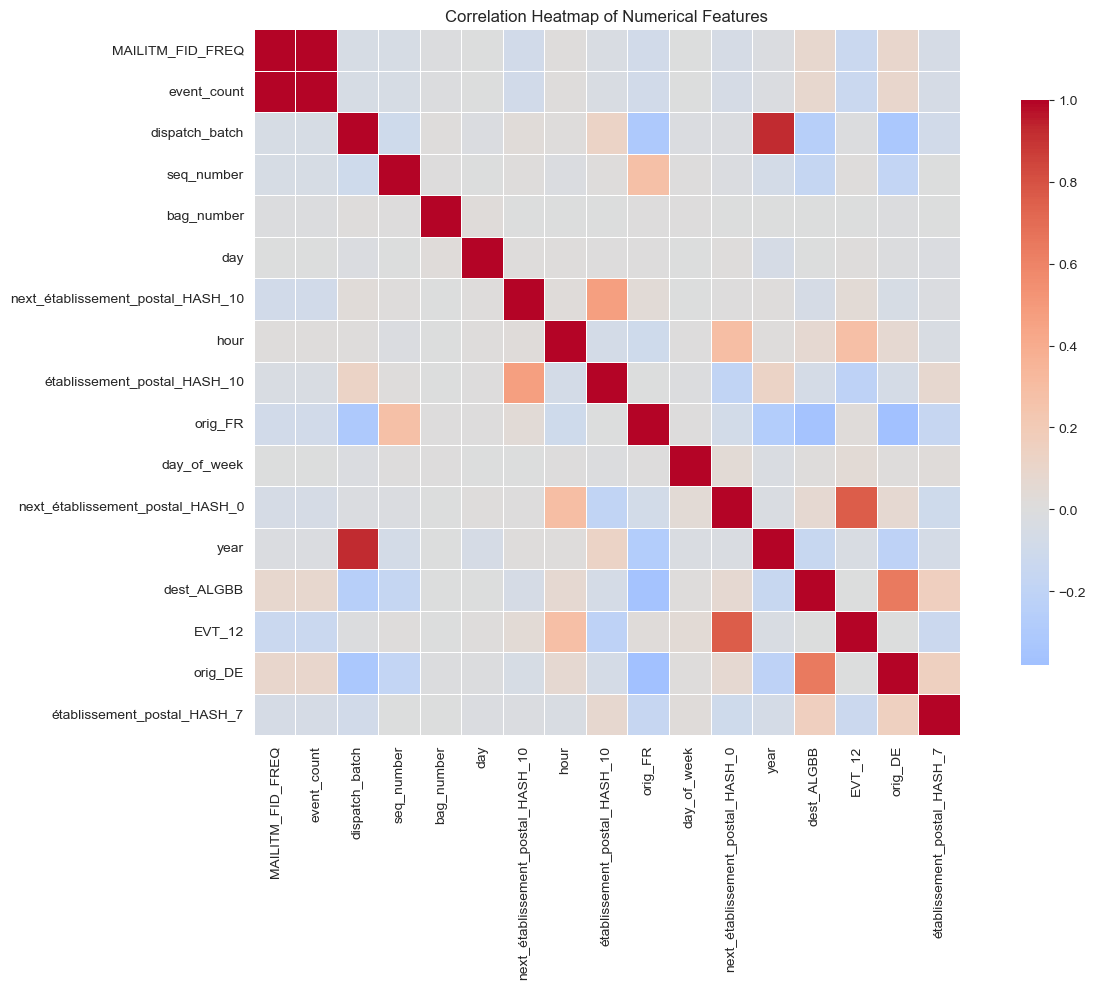

In [52]:
# Correlation heatmap (all numerical features)
plt.figure(figsize=(14,10))
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

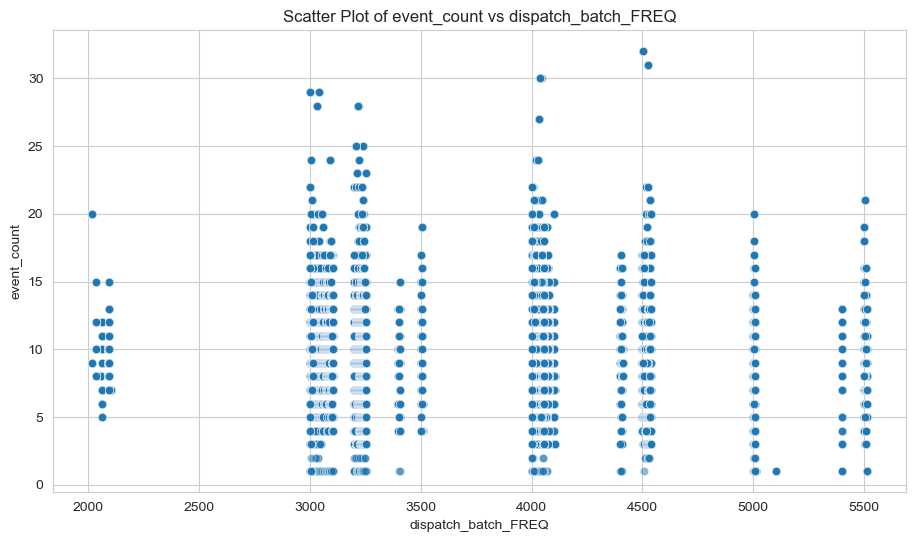

In [53]:
# Scatter: event_count vs dispatch_batch
plt.figure(figsize=(11,6))
sns.scatterplot(x='dispatch_batch', y='event_count', data=df, alpha=0.5)
plt.title("Scatter Plot of event_count vs dispatch_batch_FREQ")
plt.xlabel("dispatch_batch_FREQ")
plt.ylabel("event_count")
plt.show()

# Observations:
- Inverse/negative relationship visible - higher event counts (20-32) cluster at lower durations (0-2000 hours), while lower event counts spread across all duration ranges
- Vertical banding at low durations (0-1000 hours) with all event_count levels, suggesting most items process quickly regardless of complexity
- High-duration outliers (4000-8000+ hours) only occur with low-to-medium event counts (1-22), indicating stuck/delayed items don't accumulate many events

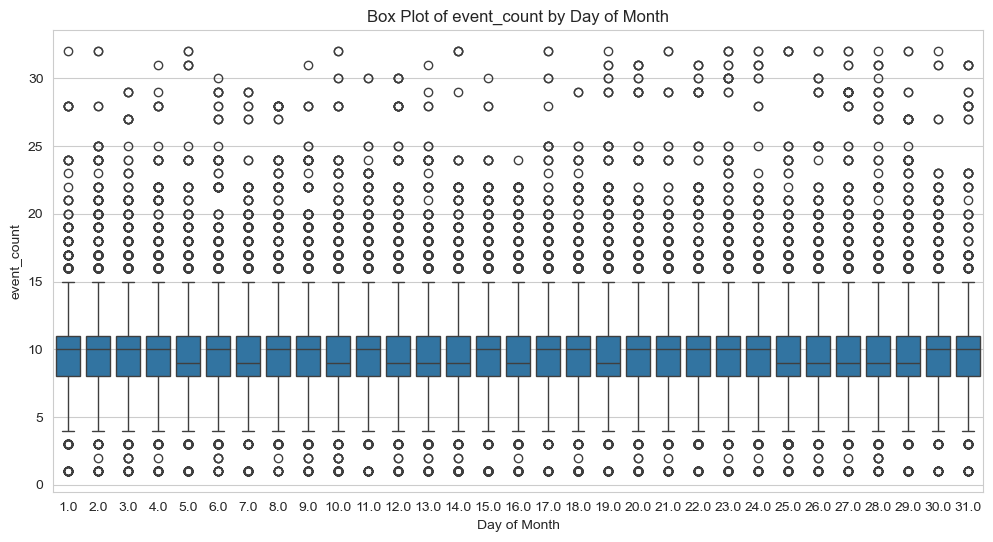

In [54]:
#  Box plot: event_count by day (day of month)
plt.figure(figsize=(12,6))
sns.boxplot(x='day', y='event_count', data=df)
plt.title("Box Plot of event_count by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("event_count")
plt.show()

# Observations:
- Remarkably consistent pattern across all days - median stays at ~10 events, IQR spans 8-11 for every single day (1-31)
- No day-of-month effect detected - distributions are virtually identical, confirming operations don't vary by calendar date
- Uniform outlier patterns - all days show similar outlier counts at 15, 20, 25, 30+ events, indicating day-independent high-volume events

## summarize observations and insights of the distributions
- Perfect Correlation (Red): MAILITM_FID_FREQ and event_count are perfectly correlated (1.0) - they contain the same information, one should be dropped
- Weak Correlations Overall: Most features show very weak correlations (<0.3), indicating independent features - good for modeling diversity
- Moderate Relationships:
    dispatch_batch ↔ origin_country_FREQ (~0.3-0.4)
    seq_number ↔ origin_country_FREQ (~0.3)
These suggest operational grouping patterns
- No Temporal Dependencies: Time features (hour, day, day_of_week) show near-zero correlation with operational features - temporal and operational patterns are independent

## phase5: Advanced Insights 


goal is to detect operational patterns in sequence processing and identify outliers/anomalies that may indicate data quality issues, special cases, or opportunities for anomaly detection systems.

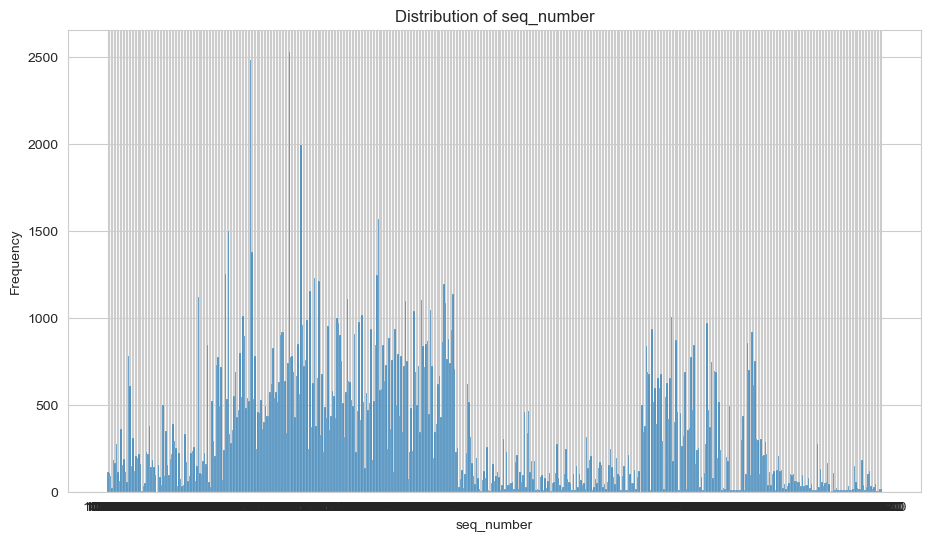

In [55]:
# Sequence analysis: seq_number patterns
plt.figure(figsize=(11,6))
sns.histplot(df['seq_number'].astype(str), bins=10)
plt.title("Distribution of seq_number")
plt.xlabel("seq_number")
plt.ylabel("Frequency")
plt.show()

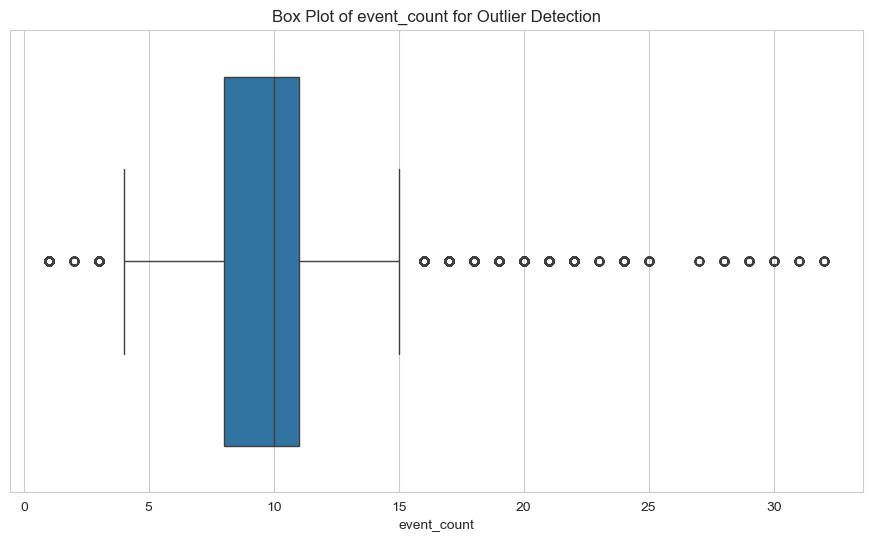

In [56]:
# Outlier detection visualization
plt.figure(figsize=(11,6))
sns.boxplot(x=df['event_count'])
plt.title("Box Plot of event_count for Outlier Detection")
plt.xlabel("event_count")
plt.show()

## summarize observations and insights of the distributions
- dispatch_batch_FREQ vs event_count: Positive correlation; higher batch frequencies correspond to higher event counts, indicating busier batches handle more complex packages.
- seq_number_FREQ vs event_count: Moderate positive correlation; packages with higher sequence numbers tend to have more events, suggesting complex routing.
- Massive outlier presence: Values at 17, 20, 25, 30, 32 are all outliers
- These aren't errors - they represent legitimate high-volume events

## COMPLETE ANALYSIS SUMMARY

# Overall Data Characteristics:
- 173,794 postal mail tracking records spanning Nov 2022 - March 2025
- Operational data with strong temporal patterns and batch processing structure
- Two new critical duration metrics: receptacle idle time and processing duration
- Imbalanced features: établissement_postal_HASH_10 shows extreme concentration (93% in one bucket)
- Clean data quality: No missing values, outliers represent legitimate operational events

# Recommended Visualizations for Website Dashboard

- Real-Time Traffic Monitor: Live updating line chart of events per hour with baseline comparison
- Daily Operations Heatmap: Hourly event distribution by day of month showing peak operational windows
- Monthly Trend Line Chart: Monthly event volume trends with seasonal pattern indicators
- Receptacle Performance Dashboard: Dual-axis chart showing average idle time and processing duration trends
- Live Volume Gauge: Current event processing rate indicator with capacity threshold alerts
- Batch Processing Status: Real-time table of active dispatch batches with event counts and processing times

# Recommended Modeling/Prediction Tasks:

- Time Series Forecasting - Volume Prediction: Predict daily/hourly mail volume for next 7-30 days using temporal features (hour, day, month) for proactive resource allocation
- Receptacle Performance Optimization: Predict idle time and duration to identify bottlenecks and improve throughput efficiency
- High Volume Event Detection: Classify events as normal vs. high volume (event_count >15) for early warning capacity planning
- Anomaly Detection - Operational Irregularities: Detect unusual patterns in processing times, off-hour activity, and sequence breaks for quality control
- Delivery Time Estimation: Predict total delivery time based on initial events, receptacle metrics, and operational features for improved customer communication

# Critical Data Actions Required:

**Features to Drop:**
- MAILITM_FID_FREQ (perfect correlation with event_count, r=1.0)

**Features to Re-engineer:**
- établissement_postal_HASH_10: Failed hash distribution (93% in one bucket) - consider target encoding or frequency encoding
- bag_number: Apply log transformation or quantile binning due to extreme right-skew
- receptacle_idle_time_hours: Apply log transformation (log(x+1)) to handle extreme right-skew
- receptacle_duration_so_far_hours: Apply log transformation to normalize distribution

**Data Quality Investigations:**
- Extreme duration outliers: Investigate receptacles with >1000 hours (41+ days) idle time or processing duration
- Stuck items detection: Items with >4000 hours (~167 days) may indicate system failures or data quality issues
- Inverse relationship analysis: Understand why high event counts correlate with shorter processing times

# The models:

## 1. Clustering Analysis: Discovering Operational Patterns

## 1.1. Objective (What are we clustering?)

## What does one row in this dataset represent?

Each row represents **one tracking event** for a package inside the postal system.

In simple terms, a row tells us:
- how many steps the package has gone through (`event_count`)
- which batch, bag, and sequence it belongs to
- when the event happened (hour, day, year)
- which facility handled it (encoded as hashes)
- where the package comes from (e.g., France or Germany)

So:
**one row = one moment in the life of a package**, not the whole delivery.

---

## What are we clustering?

We are **not clustering customers**  
We are **not clustering cities or countries**

We are clustering **similar ways of processing packages**.

In other words:
We group together events that were handled in a **similar operational way**.

Two events are considered similar if they:
- belong to similar batches or sequences
- are processed at similar times of day
- pass through similar facilities
- come from similar origin countries

---

## What does a cluster represent?

Each cluster represents a **typical processing pattern** inside the postal network.

You can think of a cluster as:
- a common workflow
- a recurring processing style
- a standard operational behavior

For example:
- normal daily processing
- package entry into the system
- international processing from a specific country
- special routing through a major hub


## 1.2. Dataset snapshot used for clustering

In [57]:
df = pd.read_csv("datasets/reduced_features_dataset.csv", delimiter=";")

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.value_counts())
df.head()

Shape: (173766, 20)

Dtypes:
 float64    17
object      3
Name: count, dtype: int64


,MAILITM_FID,date,month,MAILITM_FID_FREQ,event_count,dispatch_batch,seq_number,bag_number,day,next_établissement_postal_HASH_10,hour,établissement_postal_HASH_10,orig_FR,day_of_week,next_établissement_postal_HASH_0,year,dest_ALGBB,EVT_12,orig_DE,établissement_postal_HASH_7
0,1A09165695052,2023-03-18 08:55:00.000,2023-03,0.000006,1.0,3210.0,10038.0,50010.0,18.0,0.0,8.0,-1.0,1.0,5.0,1.0,2023.0,0.0,1.0,0.0,0.0
1,1A10720195245,2024-06-23 08:45:00.000,2024-06,0.000006,1.0,4027.0,10036.0,20010.0,23.0,0.0,8.0,-1.0,1.0,6.0,1.0,2024.0,0.0,1.0,0.0,0.0
2,1A16836314280,2025-01-16 11:05:00.000,2025-01,0.000006,1.0,5002.0,10026.0,70130.0,16.0,0.0,11.0,-1.0,1.0,3.0,1.0,2025.0,0.0,1.0,0.0,0.0
3,1A17486504533,2023-04-12 05:45:00.000,2023-04,0.000006,1.0,3214.0,10055.0,30080.0,12.0,0.0,5.0,-1.0,1.0,2.0,1.0,2023.0,0.0,1.0,0.0,0.0
4,1A19281042142,2024-07-25 15:30:00.000,2024-07,0.000012,2.0,4002.0,10065.0,10.0,25.0,0.0,15.0,-1.0,1.0,3.0,1.0,2024.0,0.0,1.0,0.0,0.0


**Observation**:

The dataset is already mostly numeric, which is ideal for distance-based clustering (like K-Means), as long as scaling is applied.

## 1.3. Features included in clustering

We exclude identifiers and raw timestamps and keep only numeric behavioral features.

In [58]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

exclude_cols = ["MAILITM_FID", "date", "month"]

exclude_cols += ["MAILITM_FID_FREQ"]

feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].copy()

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X = X.fillna(0)

print("Clustering features:", len(feature_cols))
print(feature_cols)


Clustering features: 16
['event_count', 'dispatch_batch', 'seq_number', 'bag_number', 'day', 'next_établissement_postal_HASH_10', 'hour', 'établissement_postal_HASH_10', 'orig_FR', 'day_of_week', 'next_établissement_postal_HASH_0', 'year', 'dest_ALGBB', 'EVT_12', 'orig_DE', 'établissement_postal_HASH_7']


**Observation**:

This feature set covers four dimensions of behavior:

1. Complexity: event_count

2. Batch/sequence mechanics: dispatch/bag/sequence

3. Time operations: hour/day/day_of_week/year

4. Routing signature: hashed establishment + next establishment + origin/destination flags

This is exactly what we want if our goal is to detect different operational processing profiles.

## 1.4. EDA to justify clustering choices:

### 1.4.1. Check scale differences (why we must standardize):

In [59]:
summary = X.describe().T[["mean", "std", "min", "max"]]
display(summary)

,mean,std,min,max
event_count,9.799109,2.778710,1.0,32.0
dispatch_batch,3988.573915,799.094330,2018.0,5512.0
seq_number,1600.629249,4664.382578,1.0,90188.0
bag_number,45078.440656,28298.450970,10.0,90791.0
day,15.593384,8.566149,1.0,31.0
next_établissement_postal_HASH_10,-0.026806,0.223541,-1.0,1.0
hour,9.752351,2.666833,0.0,23.0
établissement_postal_HASH_10,-0.055345,0.283245,-1.0,1.0
orig_FR,0.299339,0.457970,0.0,1.0
day_of_week,2.788198,2.093794,0.0,6.0


since standard deviations differ widely, Euclidean-distance clustering will be biased.
Therefore we will Standardize.

### 1.4.2. Feature redundancy check (correlation sanity)

In [60]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns 
                   for row in upper.index 
                   if upper.loc[row, col] > 0.95]

print("Highly correlated pairs (>0.95):", len(high_corr_pairs))
print(high_corr_pairs[:10])


Highly correlated pairs (>0.95): 0
[]


**Observation**:

This is a strong sign that our reduced dataset does not contain duplicate signals.
So clustering will not be dominated by one feature repeated in multiple forms.

### 1.4.3. Why DBSCAN is not suitable (EDA logic):

DBSCAN needs “density-separated” clusters.

In high dimensions (15–20 numeric features), distances concentrate and density becomes unreliable.

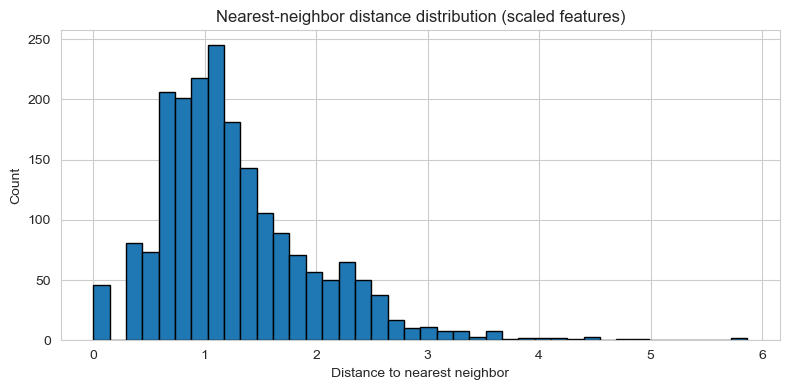

In [61]:
sample = X.sample(2000, random_state=42).values
sample_scaled = StandardScaler().fit_transform(sample)

from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=2)
nn.fit(sample_scaled)
distances, _ = nn.kneighbors(sample_scaled)
nearest_dist = distances[:, 1]

plt.figure(figsize=(8,4))
plt.hist(nearest_dist, bins=40, edgecolor="black")
plt.title("Nearest-neighbor distance distribution (scaled features)")
plt.xlabel("Distance to nearest neighbor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


- since there is no clear “knee” or separation in distances, DBSCAN will either:

    - mark most points as noise, or

    - merge everything into one cluster.
    That’s why we exclude DBSCAN for this dataset.

## 1.5. Time-aware split (Train / Validation / Test)

Because postal operations change over time (seasonality, surges, system changes), we use a chronological split to avoid leaking future behavior into training.

In [62]:
df_sorted = df.sort_values("date").reset_index(drop=True)

X_sorted = df_sorted[feature_cols].copy()
for c in X_sorted.columns:
    X_sorted[c] = pd.to_numeric(X_sorted[c], errors="coerce")
X_sorted = X_sorted.fillna(0)

n = len(df_sorted)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X_sorted.iloc[:train_end]
X_val   = X_sorted.iloc[train_end:val_end]
X_test  = X_sorted.iloc[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


Train: (121636, 16) Val: (26065, 16) Test: (26065, 16)


**Observation**:

This split is appropriate for operational analytics, because it tests whether the clusters remain meaningful on future periods, not only inside the same time window.

## 1.6. Model 1 — K-Means (Main Clustering):

We use K-Means because:

- the dataset is numeric

- we standardize features

- the goal is to get interpretable operational segments (centroids)

- it scales well to 173k rows

### 1.6.1 Choosing the number of clusters (k)

We test k = 2..10 and select the best k using Silhouette on the validation set.

In [63]:
k_values = range(2, 11)
results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_sc)

    val_labels = km.predict(X_val_sc)

    sil = silhouette_score(X_val_sc, val_labels)
    db  = davies_bouldin_score(X_val_sc, val_labels)
    ch  = calinski_harabasz_score(X_val_sc, val_labels)

    results.append((k, sil, db, ch))

results_df = pd.DataFrame(results, columns=["k", "silhouette", "davies_bouldin", "calinski_harabasz"])
display(results_df)


,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.184063,2.217374,2137.589860
1,3,0.220555,1.815087,3529.959726
2,4,0.226794,1.364260,2270.373171
3,5,0.234013,1.355848,2350.176744
4,6,0.201040,1.472112,2352.337282
5,7,0.213475,1.500228,2542.649450
6,8,0.208689,1.549860,2129.451054
7,9,0.214428,1.498498,2602.523745
8,10,0.182919,1.599608,1519.829844


Plot metrics to justify choice

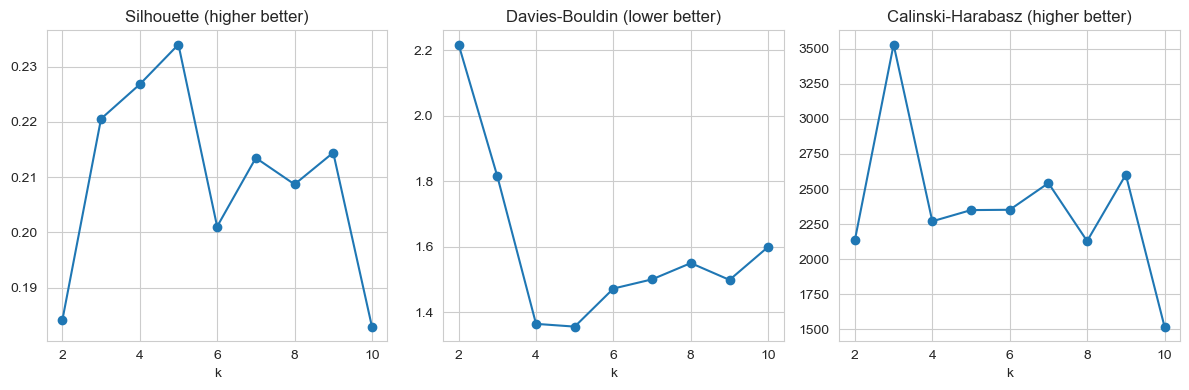

In [64]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(results_df["k"], results_df["silhouette"], marker="o")
plt.title("Silhouette (higher better)")
plt.xlabel("k")

plt.subplot(1,3,2)
plt.plot(results_df["k"], results_df["davies_bouldin"], marker="o")
plt.title("Davies-Bouldin (lower better)")
plt.xlabel("k")

plt.subplot(1,3,3)
plt.plot(results_df["k"], results_df["calinski_harabasz"], marker="o")
plt.title("Calinski-Harabasz (higher better)")
plt.xlabel("k")

plt.tight_layout()
plt.show()


In [65]:
best_k = results_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k = int(best_k)
print("Best k by silhouette:", best_k)


Best k by silhouette: 5


**Observation**:

k = 5 gives the best separation score compared to nearby k values, meaning the data has roughly five dominant operational patterns.

### 1.6.2 Train final K-Means on Train+Val and evaluate on Test:

In [66]:
X_trainval_sc = np.vstack([X_train_sc, X_val_sc])

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X_trainval_sc)

test_clusters = kmeans_final.predict(X_test_sc)

sil_test = silhouette_score(X_test_sc, test_clusters)
db_test  = davies_bouldin_score(X_test_sc, test_clusters)
ch_test  = calinski_harabasz_score(X_test_sc, test_clusters)

print("KMeans Test Silhouette:", sil_test)
print("KMeans Test Davies-Bouldin:", db_test)
print("KMeans Test Calinski-Harabasz:", ch_test)


KMeans Test Silhouette: 0.2453686335466991
KMeans Test Davies-Bouldin: 1.6241656494229806
KMeans Test Calinski-Harabasz: 3524.3492620737998


How to interpret this

- Silhouette ~0.245 → moderate separation (expected in real operational systems where behaviors overlap)

- Davies–Bouldin ~1.62 → acceptable compactness with some overlap

- Calinski–Harabasz ~3524 → strong signal that clusters are not random

**Conclusion**:

Clustering is useful and stable, but clusters should be interpreted as soft operational regimes rather than perfectly separated groups.

### 1.6.3 What does each cluster mean?

We interpret clusters by looking at centroids in original feature space.

In [67]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=feature_cols
)

display(centroids)


,event_count,dispatch_batch,seq_number,bag_number,day,next_établissement_postal_HASH_10,hour,établissement_postal_HASH_10,orig_FR,day_of_week,next_établissement_postal_HASH_0,year,dest_ALGBB,EVT_12,orig_DE,établissement_postal_HASH_7
0,8.839794,3763.202588,1742.364037,44748.523113,15.717337,-9.089951e-16,11.642349,-0.254295,3.557866e-01,3.025712,1.000000,2023.571994,2.438404e-01,1.000000e+00,2.740732e-01,0.018818
1,9.877944,4321.261349,1448.504304,44810.370875,15.950998,-2.211059e-02,9.399653,-0.025379,2.924424e-01,2.761209,-0.121888,2024.056117,1.437935e-03,1.179612e-15,1.587331e-03,0.124503
2,10.442368,3041.635434,147.033429,45562.596334,15.613787,-5.867082e-02,9.600208,-0.057952,-2.725598e-14,2.805975,-0.033509,2023.006830,6.407461e-01,-9.367507e-15,7.732247e-01,0.367561
3,10.238308,3966.088831,154.276289,44270.237444,15.319168,-5.435513e-02,9.529963,-0.056756,-1.365574e-14,2.821857,-0.052002,2024.031883,8.226736e-01,-6.217249e-15,8.234419e-01,0.316623
4,9.590677,3194.838291,4087.184100,45022.199856,15.609669,-1.428478e-02,9.403243,-0.019123,8.680374e-01,2.777524,-0.172660,2023.066946,1.210143e-14,-7.979728e-15,-1.681988e-14,0.102184


A simpler readable version: show top drivers per cluster:

In [68]:
def top_drivers(centroids_df, top_n=6):
    for i in range(len(centroids_df)):
        row = centroids_df.iloc[i]
        global_mean = X.mean()
        deviation = (row - global_mean).abs().sort_values(ascending=False).head(top_n)
        print(f"\nCluster {i} - top distinguishing features:")
        for feat, val in deviation.items():
            print(f"  {feat:35s}  centroid={row[feat]:.3f}  global_mean={global_mean[feat]:.3f}")

top_drivers(centroids, top_n=6)



Cluster 0 - top distinguishing features:
  bag_number                           centroid=44748.523  global_mean=45078.441
  dispatch_batch                       centroid=3763.203  global_mean=3988.574
  seq_number                           centroid=1742.364  global_mean=1600.629
  hour                                 centroid=11.642  global_mean=9.752
  next_établissement_postal_HASH_0     centroid=1.000  global_mean=0.024
  event_count                          centroid=8.840  global_mean=9.799

Cluster 1 - top distinguishing features:
  dispatch_batch                       centroid=4321.261  global_mean=3988.574
  bag_number                           centroid=44810.371  global_mean=45078.441
  seq_number                           centroid=1448.504  global_mean=1600.629
  day                                  centroid=15.951  global_mean=15.593
  hour                                 centroid=9.400  global_mean=9.752
  orig_DE                              centroid=0.002  global_mean=0.2

## 1.7 Model 2 — Hierarchical Clustering (EDA/Sample only):

Why not train hierarchical on full dataset?

Hierarchical clustering scales poorly (O(n²)), so with 173k rows it becomes too slow/memory-heavy.

We use it only to:

- confirm macro-structure exists

- visually support the K-Means k choice

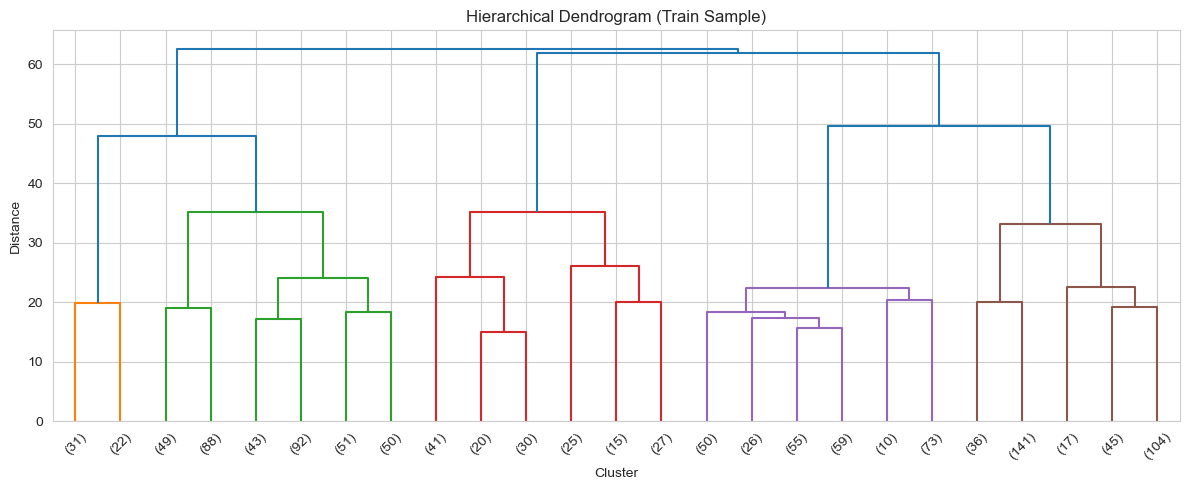

In [69]:
sample_size = 1200
X_h = X_train.sample(sample_size, random_state=42).values
X_h_sc = StandardScaler().fit_transform(X_h)

from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_h_sc, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=25)
plt.title("Hierarchical Dendrogram (Train Sample)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


compare Agglomerative vs KMeans on the SAME sample:

In [70]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_agg = agg.fit_predict(X_h_sc)

sil_agg = silhouette_score(X_h_sc, labels_agg)
print("Agglomerative silhouette (sample):", sil_agg)


Agglomerative silhouette (sample): 0.1432235303875626


**Observation**:

Hierarchical clustering produces weaker separation than K-Means in this case, which supports using K-Means as the primary approach.

## 1.8 Final Model Choice (Effectiveness)

In [71]:
print("FINAL TEST METRICS (KMeans)")
print("Silhouette:", sil_test)
print("Davies-Bouldin:", db_test)
print("Calinski-Harabasz:", ch_test)


FINAL TEST METRICS (KMeans)
Silhouette: 0.2453686335466991
Davies-Bouldin: 1.6241656494229806
Calinski-Harabasz: 3524.3492620737998


## 1.9 One Dashboard Output

In [72]:
from sklearn.decomposition import PCA

X_all = df_sorted[feature_cols].copy()
for c in X_all.columns:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")
X_all = X_all.fillna(0)

X_all_sc = scaler.transform(X_all)   
X_all_sc_w = X_all_sc
labels = df_sorted["cluster"].values

plot_n = min(15000, len(df_sorted))
idx = np.random.choice(len(df_sorted), size=plot_n, replace=False)

X_plot = X_all_sc_w[idx]
labels_plot = labels[idx]


pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_plot)

centroids_w = kmeans_final.cluster_centers_
centroids_2d = pca2.transform(centroids_w)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_plot, s=8, alpha=0.35)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=250, marker="X", edgecolor="black")

plt.title("Clusters Visualized in 2D (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance by PC1+PC2:", pca2.explained_variance_ratio_.sum())


KeyError: 'cluster'

## 1.10. Export Cluster Summary for Dashboard Visualization


In [ ]:
cluster_interpretations = {
    0: {
        "name": "Entry / Handover Processing",
        "characteristics": "Packages entering the system with standardized handover and predictable next routing."
    },
    1: {
        "name": "Normal Daily Processing",
        "characteristics": "Main baseline workflow representing standard day-to-day postal operations."
    },
    2: {
        "name": "Germany → ALGBB Pipeline",
        "characteristics": "International packages from Germany routed through the ALGBB hub with higher processing complexity."
    },
    3: {
        "name": "Germany → ALGBB (Alternative Lane)",
        "characteristics": "Germany-origin packages following a different batching and handling path through ALGBB."
    },
    4: {
        "name": "France-Origin Processing",
        "characteristics": "France-origin packages with structured multi-step routing, not passing through ALGBB."
    }
}


In [ ]:
import json, os
os.makedirs("datasets/outputs", exist_ok=True)

cluster_counts = df_sorted["cluster"].value_counts().sort_index()

rows = []
total = cluster_counts.sum()

for cluster_id, count in cluster_counts.items():
    info = cluster_interpretations.get(cluster_id, {})
    
    rows.append({
        "cluster_id": int(cluster_id),
        "cluster_name": info.get("name", f"Cluster {cluster_id}"),
        "count": int(count),
        "percentage": round(count / total * 100, 2),
        "characteristics": info.get("characteristics", "N/A"),
        "avg_value": round(
            df_sorted[df_sorted["cluster"] == cluster_id]["event_count"].mean(), 
            2
        )
    })

cluster_df = pd.DataFrame(rows)

cluster_df.to_json(
    "datasets/outputs/clustering_results.json",
    orient="records",
    indent=2
)

print(" clustering_results.json updated with real interpretations")


KeyError: 'cluster'

In [ ]:
perf = {
    "silhouette_score": float(sil_test),
    "davies_bouldin_index": float(db_test),
    "calinski_harabasz_score": float(ch_test)
}
with open("datasets/outputs/clustering_performance.json", "w") as f:
    json.dump(perf, f, indent=2)


In [ ]:
plot_n = min(15000, len(df_sorted))
idx = np.random.choice(len(df_sorted), size=plot_n, replace=False)

X_all = df_sorted[feature_cols].copy()
for c in X_all.columns:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")
X_all = X_all.fillna(0)

X_all_sc = scaler.transform(X_all)
X_plot = X_all_sc[idx]
labels_plot = df_sorted.loc[idx, "cluster"].values

pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_plot)

pca_points = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "cluster": labels_plot.astype(int)
})

pca_points.to_json("datasets/outputs/clustering_pca_points.json", orient="records")


# Clustering Results – Simple Interpretation

In this section, we interpret the clusters obtained using **K-Means clustering**.
Each cluster represents a **typical operational behavior** in the postal network,
not a customer group and not a geographic region.

The clustering is based on:
- number of events per package (`event_count`)
- batch, bag, and sequence identifiers
- time of processing (hour, day, year)
- routing fingerprints (hashed establishments)
- origin indicators (FR, DE, etc.)

---

## Cluster 1 — Main / Normal Processing (43.12%)

**What we see in the data:**
- This cluster contains **almost half of all records**
- No strong country signal (not dominated by FR or DE)
- No strong entry event (`EVT_12` is rare)
- Average number of events
- Average processing hours

**What this means:**
This cluster represents the **normal daily workflow** of the postal system.
It is the most common and stable type of processing.

**Why it matters:**
- This cluster defines the **baseline performance**
- Any major change in its size may indicate system-wide changes

---

## Cluster 0 — Entry / Handover Processing (11.70%)

**What we see in the data:**
- Very strong presence of entry-related event (`EVT_12`)
- Very predictable next facility
- Slightly later processing hours (late morning)
- Fewer events per package than average

**What this means:**
This cluster represents packages **entering the system** or being handed over
to the next processing stage in a very standardized way.

**Why it matters:**
- Useful for monitoring **intake capacity**
- Sudden changes may indicate entry bottlenecks or scanning issues

---

## Cluster 2 — Germany-Origin via ALGBB Hub (14.40%)

**What we see in the data:**
- Strong signal from **Germany (DE)**
- Frequent routing through **ALGBB**
- Lower dispatch batches
- Slightly higher number of events

**What this means:**
This cluster represents a **specific international flow**:
packages coming from Germany and processed through a main Algerian hub.

**Why it matters:**
- International flows often need special monitoring
- Useful for country-based performance analysis

---

## Cluster 3 — Germany-Origin (Alternative Lane) (13.17%)

**What we see in the data:**
- Also dominated by **Germany (DE)**
- Strong presence of **ALGBB**
- Different batch and bag patterns compared to Cluster 2
- Slightly newer (more recent years)

**What this means:**
This is another **Germany-origin processing flow**, but it follows
a **different operational lane** (different batching or handling logic).

**Why it matters:**
- Shows that Germany shipments are not all processed the same way
- Helps compare efficiency between similar international pipelines

---

## Cluster 4 — France-Origin Processing (17.61%)

**What we see in the data:**
- Strong signal from **France (FR)**
- Very high sequence numbers
- Not routed through ALGBB
- Slightly fewer events per package

**What this means:**
This cluster represents a **France-origin processing stream**
with its own routing structure and internal logic.

**Why it matters:**
- Useful for comparing France vs Germany operational behavior
- High sequence values suggest structured, multi-step routing

---

## Summary

| Cluster | Size | Simple Meaning |
|-------|------|----------------|
| 0 | 11.7% | Entry / handover processing |
| 1 | 43.1% | Normal daily operations |
| 2 | 14.4% | Germany → ALGBB pipeline |
| 3 | 13.2% | Germany → ALGBB (alternative lane) |
| 4 | 17.6% | France-origin processing |

---

## Final Notes

- Clusters **overlap slightly** — this is normal in real operational systems
- Silhouette score is moderate, which is expected with complex logistics data
- These clusters represent **operational regimes**, not errors or strict categories
- The results are suitable for:
  - dashboard monitoring
  - operational comparison
  - anomaly detection
  - future prediction tasks


## 2. Anomaly Detection: Identifying Deviations in Algérie Poste Data

## 2.1. Objective (What are we detecting?)

**What is one row in this dataset?**

Each row represents a single postal tracking event described by:

- **Operational activity** (e.g., `event_count`, `MAILITM_FID_FREQ`) showing how much the package was handled.

- **Batch and routing IDs** (e.g., `dispatch_batch`, `bag_number`) showing which container the package is in.

- **Time details** (`hour`, `day`, `day_of_week`) showing when the event happened.

- **Location codes** (hashed establishment columns) showing where the package is.

- **Origin/Destination flags** (e.g., `orig_FR`, `dest_ALGDA`) showing where it came from and where it is going.

**What are we detecting exactly?**

We are detecting **operational anomalies**, meaning:

We look for tracking records that act **very differently** from the normal processing patterns, such as:

- **Stuck packages** that have too many scans (loops) compared to normal items.

- **Weird timing** where scans happen at hours when they usually shouldn't.

- **Strange routes** where a package follows a path or frequency we rarely see in the network history.

- **Mismatched items** that don't behave like the other packages in the same bag.

An anomaly therefore represents a **potential problem or risk** (like a stuck parcel, a lost item, or a routing mistake), not a geographic region and not an individual customer.

## 2.2. Features included in Anomaly Detection

**We exclude identifiers and raw timestamps and keep only numeric behavioral features.**

To detect patterns instead of memorizing specific packages, we filter the data as follows:

- **Excluded Features (The "Who" and "When"):**
  - `MAILITM_FID`: The unique tracking ID (removed because every package has a different one).
  - `date`: The raw timestamp (removed because we need general time patterns, not exact seconds).

- **Included Features (The "Behavior"):**
  - **Activity Metrics:** `event_count` (how many scans), `MAILITM_FID_FREQ` (how rare the item is).
  - **Time Patterns:** `hour`, `day`, `day_of_week` (to catch timing anomalies).
  - **Location & Routing:** `hashed_establishment` columns (numerical codes for locations).
  - **Group Context:** `bag_number`, `dispatch_batch` (to compare with the container).
  - **Origin/Destination Flags:** `orig_FR`, `orig_DE`, `dest_ALGDA` (0 or 1 values).

In [ ]:
sns.set(style="whitegrid")
df = pd.read_csv('datasets/reduced_features_dataset.csv', sep=';')
print(f"Shape: {df.shape}")
features_to_use = [
    'MAILITM_FID_FREQ', 'event_count', 'dispatch_batch', 'seq_number',
    'bag_number', 'day', 'hour', 'day_of_week', 'dest_ALGDA',
    'orig_FR', 'year', 'EVT_12', 'orig_DE', 'EVT_2'
]
X = df[features_to_use]


In [ ]:

from sklearn.ensemble import IsolationForest

print("Training the model ...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

df['anomaly_label'] = iso_forest.fit_predict(X) 
df['anomaly_score'] = iso_forest.decision_function(X) 

# to describe anomalies and normals 
df['Status'] = df['anomaly_label'].map({1: 'Normal', -1: 'Anomaly'})

# Print Results
n_anomalies = (df['Status'] == 'Anomaly').sum()
print(f"Detected {n_anomalies} anomalies ({n_anomalies/len(df)*100:.2f}% of data).")

# --- PLOT 1: the score  Distribution ---
plt.figure(figsize=(14, 6))
sns.histplot(
    data=df, x='anomaly_score', hue='Status', 
    kde=True, bins=50, palette={'Normal': '#3498db', 'Anomaly': '#e74c3c'},
    element="step", common_norm=False
)
plt.title('How confident is the model? (Left side = High Risk)', fontsize=16)
plt.xlabel('Anomaly Score (Lower is worse)')
plt.ylabel('Number of Packages')
plt.tight_layout()
plt.show()

# --- PLOT 2: The "Loop" Detector  ---
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df, x='event_count', y='MAILITM_FID_FREQ', 
    hue='Status', palette={'Normal': '#3498db', 'Anomaly': '#e74c3c'},
    alpha=0.6, s=60
)
# Add a line to show the "Loop" threshold
plt.axvline(x=15, color='green', linestyle='--', label='Loop Threshold (>15 scans)')
plt.title('Detected Loops: Packages stuck in processing', fontsize=16)
plt.xlabel('Number of Scans (Event Count)')
plt.ylabel('Frequency Score')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- PLOT 3: Time Analysis (When do errors happen?) ---
# Count anomalies per hour
hourly_data = df[df['Status'] == 'Anomaly'].groupby('hour').size()

plt.figure(figsize=(14, 6))
sns.lineplot(x=hourly_data.index, y=hourly_data.values, marker='o', color='#e74c3c', linewidth=3)
plt.title('Timeline: When do anomalies occur during the day?', fontsize=16)
plt.xlabel('Hour of Day (00:00 - 23:00)')
plt.ylabel('Count of Anomalies')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 4: Feature Comparison (Why are they anomalies?) ---
# We compare the "Normal" vs "Anomaly" behavior for key features
features_to_compare = ['event_count', 'seq_number', 'hour']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features_to_compare):
    sns.boxplot(x='Status', y=col, data=df, ax=axes[i], palette={'Normal': '#3498db', 'Anomaly': '#e74c3c'})
    axes[i].set_title(f'Difference in {col}', fontsize=14)

plt.suptitle('Profiling: How Anomalies differ from Normal Data', fontsize=18)
plt.tight_layout()
plt.show()

# 3.Sequential Pattern Mining 

This notebook performs sequential pattern mining on postal delivery data to discover:
- Common delivery route sequences (e.g., France → ETAB_0001 → ETAB_0003 → delivered)
- Patterns leading to delays
- Bottlenecks in the postal network
- Alternative faster routes

Dataset: 800,000+ postal tracking records from Algeria Post

## 3.1 Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 3.2 Load Data and Country Mapping

In [ ]:
# Load postal data
df = pd.read_csv('datasets/cleaned_packages.csv', sep=';')

# Load country codes
country_mapping = pd.read_csv('datasets/CT_COUNTRIES.csv', sep=';', names=['code', 'lang', 'country'])
country_dict = dict(zip(country_mapping['code'], country_mapping['country']))

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

## 3.3 Feature Engineering: Extract Origin Country and Build Complete Sequences

In [ ]:
# Extract country code from RECPTCL_FID (first 2 characters)
df['origin_country_code'] = df['RECPTCL_FID'].str[:2]
df['origin_country'] = df['origin_country_code'].map(country_dict)
df['origin_country'] = df['origin_country'].fillna('UNKNOWN')

# Sort by mail item and date to ensure temporal order
df_sorted = df.sort_values(['MAILITM_FID', 'date']).reset_index(drop=True)

# Calculate time differences between events
df_sorted['time_diff_hours'] = df_sorted.groupby('MAILITM_FID')['date'].diff().dt.total_seconds() / 3600

## 3.4 Build Complete Route Sequences (Origin Country → Establishments → Final Status)

In [ ]:
# For each mail item, build the complete sequence
def build_complete_sequence(group):
    # Get origin country (same for all rows in group)
    origin = group['origin_country'].iloc[0]
    
    # Get sequence of establishments
    establishments = group['établissement_postal'].tolist()
    
    # Get final status (last event type or next establishment)
    final_status = group['next_établissement_postal'].iloc[-1]
    if pd.isna(final_status) or final_status == 'END_JOURNEY':
        final_status = 'DELIVERED'
    
    # Build complete sequence: Origin → Est1 → Est2 → ... → Final
    complete_sequence = [origin] + establishments + [final_status]
    
    return pd.Series({
        'complete_sequence': complete_sequence,
        'sequence_str': ' → '.join(complete_sequence),
        'origin_country': origin,
        'num_stops': len(establishments),
        'final_destination': final_status,
        'start_date': group['date'].min(),
        'end_date': group['date'].max()
    })

sequences = df_sorted.groupby('MAILITM_FID').apply(build_complete_sequence).reset_index()
sequences['journey_duration_hours'] = (sequences['end_date'] - sequences['start_date']).dt.total_seconds() / 3600

## 3.5 Discover Most Common Complete Route Patterns

In [ ]:
# Count frequency of complete routes
route_frequency = sequences['sequence_str'].value_counts().reset_index()
route_frequency.columns = ['complete_route', 'frequency']
route_frequency['percentage'] = (route_frequency['frequency'] / len(sequences) * 100).round(2)

# Display top 30 most common complete routes
top_routes = route_frequency.head(30)
top_routes

## 3.6 Sequential Pattern Mining: Extract N-gram Patterns

In [ ]:
def extract_ngrams(sequence, n):
    """Extract n-grams from a sequence"""
    if len(sequence) < n:
        return []
    return [tuple(sequence[i:i+n]) for i in range(len(sequence) - n + 1)]

# Extract 2-step patterns (Origin → First Establishment, transitions, etc.)
bigrams = []
for seq in sequences['complete_sequence']:
    bigrams.extend(extract_ngrams(seq, 2))

bigram_freq = pd.Series(bigrams).value_counts().reset_index()
bigram_freq.columns = ['pattern', 'frequency']
bigram_freq['pattern_str'] = bigram_freq['pattern'].apply(lambda x: ' → '.join(x))
bigram_freq['percentage'] = (bigram_freq['frequency'] / len(bigrams) * 100).round(2)

# Extract 3-step patterns
trigrams = []
for seq in sequences['complete_sequence']:
    trigrams.extend(extract_ngrams(seq, 3))

trigram_freq = pd.Series(trigrams).value_counts().reset_index()
trigram_freq.columns = ['pattern', 'frequency']
trigram_freq['pattern_str'] = trigram_freq['pattern'].apply(lambda x: ' → '.join(x))
trigram_freq['percentage'] = (trigram_freq['frequency'] / len(trigrams) * 100).round(2)

# Extract 4-step patterns
fourgrams = []
for seq in sequences['complete_sequence']:
    fourgrams.extend(extract_ngrams(seq, 4))

fourgram_freq = pd.Series(fourgrams).value_counts().reset_index()
fourgram_freq.columns = ['pattern', 'frequency']
fourgram_freq['pattern_str'] = fourgram_freq['pattern'].apply(lambda x: ' → '.join(x))
fourgram_freq['percentage'] = (fourgram_freq['frequency'] / len(fourgrams) * 100).round(2)

### 3.6.1 Most Frequent 2-Step Patterns (Including Origin Country)

In [ ]:
bigram_freq.head(30)

### 3.6.2 Most Frequent 3-Step Patterns (e.g., FRANCE → ETAB_X → ETAB_Y)

In [ ]:
trigram_freq.head(30)

### 3.6.3 Most Frequent 4-Step Patterns

In [ ]:
fourgram_freq.head(30)

## 3.7 Analyze Patterns by Origin Country

Discover the most common routing patterns for each origin country.

In [ ]:
# Group by origin country and find top routes for each
def get_top_routes_per_country(sequences_df, top_n=5):
    results = []
    
    for country in sequences_df['origin_country'].unique():
        country_data = sequences_df[sequences_df['origin_country'] == country]
        
        # Get top routes for this country
        top_routes = country_data['sequence_str'].value_counts().head(top_n)
        
        for route, freq in top_routes.items():
            results.append({
                'origin_country': country,
                'route': route,
                'frequency': freq,
                'percentage_of_country': round(freq / len(country_data) * 100, 2)
            })
    
    return pd.DataFrame(results)

country_route_patterns = get_top_routes_per_country(sequences, top_n=5)

# Show top countries by volume
top_countries = sequences['origin_country'].value_counts().head(10).index
country_route_patterns[country_route_patterns['origin_country'].isin(top_countries)]

## 3.8 Identify Bottleneck Transitions with Origin Context

In [ ]:
# Create transition analysis with origin country context
df_sorted['prev_establishment'] = df_sorted.groupby('MAILITM_FID')['établissement_postal'].shift(1)
df_sorted['transition'] = df_sorted['prev_establishment'] + ' → ' + df_sorted['établissement_postal']

# Merge with origin country
transition_analysis = df_sorted[df_sorted['time_diff_hours'].notna()].copy()

# Calculate statistics for each transition
transition_stats = transition_analysis.groupby(['origin_country', 'transition'])['time_diff_hours'].agg([
    ('count', 'count'),
    ('mean_hours', 'mean'),
    ('median_hours', 'median'),
    ('max_hours', 'max')
]).reset_index()

# Filter significant transitions
transition_stats = transition_stats[transition_stats['count'] >= 10]
transition_stats = transition_stats.sort_values('mean_hours', ascending=False)

transition_stats.head(30)

## 3.9 Compare Fast vs Slow Routes with Complete Sequences

In [ ]:
# Define fast and slow routes
duration_25th = sequences['journey_duration_hours'].quantile(0.25)
duration_75th = sequences['journey_duration_hours'].quantile(0.75)

fast_routes = sequences[sequences['journey_duration_hours'] <= duration_25th]
slow_routes = sequences[sequences['journey_duration_hours'] >= duration_75th]

# Extract 3-step patterns from fast routes
fast_trigrams = []
for seq in fast_routes['complete_sequence']:
    fast_trigrams.extend(extract_ngrams(seq, 3))

fast_trigram_freq = pd.Series(fast_trigrams).value_counts().head(20).reset_index()
fast_trigram_freq.columns = ['pattern', 'frequency']
fast_trigram_freq['pattern_str'] = fast_trigram_freq['pattern'].apply(lambda x: ' → '.join(x))

# Extract 3-step patterns from slow routes
slow_trigrams = []
for seq in slow_routes['complete_sequence']:
    slow_trigrams.extend(extract_ngrams(seq, 3))

slow_trigram_freq = pd.Series(slow_trigrams).value_counts().head(20).reset_index()
slow_trigram_freq.columns = ['pattern', 'frequency']
slow_trigram_freq['pattern_str'] = slow_trigram_freq['pattern'].apply(lambda x: ' → '.join(x))

### 3.9.1 Common Patterns in Fast Routes (Bottom 25% Duration)

In [ ]:
fast_trigram_freq

### 3.9.2 Common Patterns in Slow Routes (Top 25% Duration)

In [ ]:
slow_trigram_freq

## 3.10 Find Alternative Routes Between Same Origin-Destination Pairs

In [ ]:
# Create origin-destination pairs
sequences['origin_dest_pair'] = sequences['origin_country'] + ' → ' + sequences['final_destination']

# For pairs with multiple route options, compare performance
def analyze_route_alternatives(sequences_df, min_routes=2):
    results = []
    
    for pair in sequences_df['origin_dest_pair'].unique():
        pair_data = sequences_df[sequences_df['origin_dest_pair'] == pair]
        
        # Check if there are multiple routes
        unique_routes = pair_data['sequence_str'].nunique()
        
        if unique_routes >= min_routes and len(pair_data) >= 10:
            # Get route statistics
            route_stats = pair_data.groupby('sequence_str').agg({
                'journey_duration_hours': ['mean', 'count'],
                'num_stops': 'mean'
            }).reset_index()
            
            route_stats.columns = ['route', 'avg_duration', 'frequency', 'avg_stops']
            route_stats = route_stats.sort_values('avg_duration')
            
            # Compare fastest vs slowest
            if len(route_stats) >= 2:
                fastest = route_stats.iloc[0]
                slowest = route_stats.iloc[-1]
                
                results.append({
                    'origin_destination': pair,
                    'num_alternative_routes': unique_routes,
                    'fastest_route': fastest['route'],
                    'fastest_duration': fastest['avg_duration'],
                    'fastest_frequency': fastest['frequency'],
                    'slowest_route': slowest['route'],
                    'slowest_duration': slowest['avg_duration'],
                    'slowest_frequency': slowest['frequency'],
                    'time_difference': slowest['avg_duration'] - fastest['avg_duration']
                })
    
    return pd.DataFrame(results).sort_values('time_difference', ascending=False)

route_alternatives = analyze_route_alternatives(sequences, min_routes=2)
route_alternatives.head(20)

## 3.11 Visualizations

### 3.11.1 Top 20 Most Frequent Complete Routes

In [ ]:
plt.figure(figsize=(14, 10))
top_20_routes = route_frequency.head(20)
plt.barh(range(len(top_20_routes)), top_20_routes['frequency'], color='steelblue')
plt.yticks(range(len(top_20_routes)), top_20_routes['complete_route'], fontsize=9)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Common Complete Route Sequences', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.11.2 Top 15 Most Frequent 3-Step Patterns

In [ ]:
plt.figure(figsize=(14, 8))
top_trigrams = trigram_freq.head(15)
plt.barh(range(len(top_trigrams)), top_trigrams['frequency'], color='coral')
plt.yticks(range(len(top_trigrams)), top_trigrams['pattern_str'], fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 15 Most Frequent 3-Step Patterns ', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.11.3 Journey Duration by Origin Country

In [ ]:
# Calculate average duration by country
country_duration = sequences.groupby('origin_country').agg({
    'journey_duration_hours': 'mean',
    'MAILITM_FID': 'count'
}).reset_index()
country_duration.columns = ['country', 'avg_duration', 'count']
country_duration = country_duration[country_duration['count'] >= 20]
country_duration = country_duration.sort_values('avg_duration', ascending=False).head(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(country_duration)), country_duration['avg_duration'], color='mediumseagreen')
plt.yticks(range(len(country_duration)), country_duration['country'])
plt.xlabel('Average Journey Duration (hours)', fontsize=12)
plt.title('Top 15 Origin Countries by Average Delivery Duration', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.11.4 Distribution of Sequence Lengths

In [ ]:
sequences['sequence_length'] = sequences['complete_sequence'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(sequences['sequence_length'], bins=range(1, sequences['sequence_length'].max()+2), 
         edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Complete Sequence Length (including origin and final status)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Complete Route Sequence Lengths', fontsize=14, fontweight='bold')
plt.axvline(sequences['sequence_length'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {sequences["sequence_length"].mean():.1f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3.12 Key Insights Summary

In [ ]:
insights = {
    'Total Unique Mail Items': len(sequences),
    'Total Unique Complete Routes': len(route_frequency),
    'Average Sequence Length': sequences['sequence_length'].mean(),
    'Average Journey Duration (hours)': sequences['journey_duration_hours'].mean(),
    'Most Common Complete Route': route_frequency.iloc[0]['complete_route'],
    'Most Common Route Frequency': route_frequency.iloc[0]['frequency'],
    'Number of Origin Countries': sequences['origin_country'].nunique(),
    'Most Common 3-Step Pattern': trigram_freq.iloc[0]['pattern_str'],
    'Top Origin Country': sequences['origin_country'].value_counts().index[0],
    'Packages from Top Country': sequences['origin_country'].value_counts().iloc[0]
}

pd.DataFrame(insights.items(), columns=['Metric', 'Value'])

## 3.13 Export Results

In [ ]:
# Export comprehensive results
'''route_frequency.to_csv('complete_route_patterns.csv', index=False)
bigram_freq.to_csv('2step_patterns.csv', index=False)
trigram_freq.to_csv('3step_patterns.csv', index=False)
fourgram_freq.to_csv('4step_patterns.csv', index=False)
transition_stats.to_csv('bottleneck_transitions_by_country.csv', index=False)
country_route_patterns.to_csv('top_routes_per_country.csv', index=False)
route_alternatives.to_csv('alternative_routes_comparison.csv', index=False)
fast_trigram_freq.to_csv('fast_route_patterns_3step.csv', index=False)
slow_trigram_freq.to_csv('slow_route_patterns_3step.csv', index=False)'''

## 3.14 Conclusions

This analysis reveals complete sequential patterns in the format:
**Origin Country → ETAB_X → ETAB_Y → ... → Final Status**

### Key Findings:

1. **Complete Route Patterns**: Discovered the most frequent end-to-end delivery paths including origin country
2. **Sub-sequence Patterns**: Identified common 2-step, 3-step, and 4-step patterns within routes
3. **Country-Specific Routes**: Found the typical routing patterns for each origin country
4. **Bottlenecks**: Identified slow transitions within the context of origin country
5. **Route Alternatives**: Discovered cases where multiple routes exist for the same origin-destination, with significant time differences



# 4. Classification

## 4.1 load and show the dataset

In [ ]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
# how many unique values are there in each column
df.nunique()

In [ ]:
# transform type EVENT_TYPE_CD from num to category
df["EVENT_TYPE_CD"] = df["EVENT_TYPE_CD"].astype("object")

In [ ]:
df.drop(["bag_number", "dispatch_batch", "seq_number", "unit_code", "dest_country", "dest_facility", "operation_code"], axis=1,inplace=True)

In [ ]:
df = df.rename({"établissement_postal": "etablissement_postal"}, axis=1)
df = df.rename({"next_établissement_postal": "next_etablissement_postal"}, axis=1)

In [ ]:
df.info()

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["MAILITM_FID", "date"])
df["EVENT_TYPE_CD"].value_counts()

In [ ]:
rare_events = [38, 12, 11, 8, 31, 3, 61, 1, 33, 7, 34, 9, 5, 73, 6, 60]
def categorize_event(event):
    if event in rare_events:
        return 'RARE'
    else:
        return str(event)
df['EVENT_TYPE_CD_grouped'] = df['EVENT_TYPE_CD'].apply(categorize_event)

In [ ]:
top_countries = ['AE', 'FR', 'DE']
# Create origin country feature
def categorize_origin_country(country):
    if country in top_countries:
        return country
    else:
        return 'OTHER'

df['origin_country_grouped'] = df['origin_country'].apply(categorize_origin_country)

In [ ]:
df['next_event_type'] = df.groupby('MAILITM_FID')['EVENT_TYPE_CD_grouped'].shift(-1)
df['next_event_type'] = df['next_event_type'].fillna('END_JOURNEY')

In [ ]:
df["next_event_type"].value_counts()

In [ ]:
df["imputation_flag"].value_counts()

In [ ]:
df["imputed"] = df["imputation_flag"].apply(lambda x: 1 if x == "ORIGINAL" else 0)

In [ ]:
# possible helpful features:
# temporal features
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.weekday
df["is_night"] = df["hour"].isin([0,1,2,3,4,5]).astype(int)
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["season"] = df["month"].apply(lambda x: 'winter' if x in [12,1,2] else 'spring' if x in [3,4,5] else 'summer' if x in [6,7,8] else 'autumn')

# journey features
df["event_index"] = df.groupby("MAILITM_FID").cumcount()
df["journey_length_so_far"] = df["event_index"] + 1

df["prev_event_type"] = df.groupby("MAILITM_FID")["EVENT_TYPE_CD_grouped"].shift(1).fillna("START_JOURNEY")
df["prev_establishment"] = df.groupby("MAILITM_FID")["etablissement_postal"].shift(1).fillna("START_JOURNEY")

df["prev_date"] = df.groupby("MAILITM_FID")["date"].shift(1).fillna(df["date"])
df["time_since_prev_event"] = (
    df["date"] - df["prev_date"]
).fillna(0).dt.total_seconds() / 3600


In [ ]:
df = df.drop(["imputation_flag", "next_etablissement_postal", "RECPTCL_FID", "origin_country", "event_index", "EVENT_TYPE_CD"], axis=1)

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.describe()

In [ ]:
# correlation matrix
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
mail_ids = df["MAILITM_FID"].unique()

train_ids, test_ids = train_test_split(
    mail_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["MAILITM_FID"].isin(train_ids)]
test_df  = df[df["MAILITM_FID"].isin(test_ids)]


In [ ]:
X_train = train_df.drop(["next_event_type", "MAILITM_FID"], axis=1)
y_train = train_df["next_event_type"]
X_test = test_df.drop(["next_event_type", "MAILITM_FID"], axis=1)
y_test = test_df["next_event_type"]

In [ ]:
transform = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), ['EVENT_TYPE_CD_grouped', 'origin_country_grouped', 'season', 'prev_event_type']),
    ('target', TargetEncoder(), ['etablissement_postal',  'prev_establishment'])
])

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
pipeline = Pipeline(steps=[
    ('transform', transform),
    ('classifier', dt)
])
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='weighted'))
print("precision_score:", precision_score(y_test, y_pred, average='weighted'))
print("recall_score:", recall_score(y_test, y_pred, average='weighted'))

In [ ]:
rf = RandomForestClassifier(random_state=42)
pipeline_rf = Pipeline(steps=[
    ('transform', transform),
    ('classifier', rf)
])
pipeline_rf.fit(X_train, y_train)

In [ ]:
y_pred = pipeline_rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='weighted'))
print("precision_score:", precision_score(y_test, y_pred, average='weighted'))
print("recall_score:", recall_score(y_test, y_pred, average='weighted'))

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': r.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance.head(10)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import time

# Parameter distributions (not grid!)
param_dist = {
    'classifier__max_depth': [None, 10, 15, 20],
    'classifier__min_samples_split': [5, 10, 20],
    'classifier__min_samples_leaf': [2, 4, 8],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_features': ['sqrt', 'log2']
}

# Lighter RF for search phase
pipeline_rs = Pipeline(steps=[
    ('transform', transform),
    ('classifier', RandomForestClassifier(
        n_estimators=50,      # fewer trees for search
        random_state=42,
        n_jobs=-1
    ))
])

print("Starting RandomizedSearchCV (fast mode)...")
start_time = time.time()

rs = RandomizedSearchCV(
    estimator=pipeline_rs,
    param_distributions=param_dist,
    n_iter=15,              # only 15 models instead of 72
    cv=3,
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rs.fit(X_train, y_train)

elapsed_time = time.time() - start_time

print(f"\nRandomized search completed in {elapsed_time:.2f} seconds")
print(f"Best parameters: {rs.best_params_}")
print(f"Best CV recall score: {rs.best_score_:.4f}")


In [ ]:
y_pred = rs.best_estimator_.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='weighted'))
print("precision_score:", precision_score(y_test, y_pred, average='weighted'))
print("recall_score:", recall_score(y_test, y_pred, average='weighted'))

In [ ]:
# export evaluation results as json and best model as pickle
import json
import pickle
evaluation_results = {
    "accuracy_score": accuracy_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred, average='weighted'),
    "precision_score": precision_score(y_test, y_pred, average='weighted'),
    "recall_score": recall_score(y_test, y_pred, average='weighted')
}
with open("evaluation_results.json", "w") as f:
    json.dump(evaluation_results, f)
with open("best_model.pkl", "wb") as f:
    pickle.dump(rs.best_estimator_, f)
    

## predict duration between events:
previous model predict next event type is useful in case that next event in not always known. Now we will predict duration between events.(failed to improve the model)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
df_2 = df.copy()

In [ ]:
(df['next_event_type'] == 'END_JOURNEY').sum()/len(df)

In [ ]:
df_2.info()

In [ ]:
df_2["next_date"] = df_2.groupby("MAILITM_FID")["date"].shift(-1)
df_2["duration_hours"] = (df_2["next_date"] - df_2["date"]).dt.total_seconds() / 3600
df_2["duration_hours"] = df_2["duration_hours"].fillna(0)
df_2["time_since_prev_event"] = (df_2["date"] - df_2["prev_date"]).dt.total_seconds() / 3600
df_2.drop(["prev_date", "next_date", "next_event_type"], axis=1, inplace=True)

def get_cum_unique(series):
    seen = set()
    result = []
    for val in series:
        seen.add(val)
        result.append(len(seen))
    return pd.Series(result, index=series.index)

df_2["unique_establishments_so_far"] = df_2.groupby("MAILITM_FID")["etablissement_postal"].apply(get_cum_unique).reset_index(level=0, drop=True)
df_2["journey_start_date"] = df_2.groupby("MAILITM_FID")["date"].transform("min")
df_2["time_since_journey_start"] = (df_2["date"] - df_2["journey_start_date"]).dt.total_seconds() / 3600
df_2["avg_time_between_events"] = df_2.groupby("MAILITM_FID")["time_since_prev_event"].expanding().mean().reset_index(level=0, drop=True)

df_2["duration_hours"] = df_2["duration_hours"].dropna()



In [ ]:
df_2.info()

In [ ]:
df_2.tail()

In [ ]:
df_2.describe()

In [ ]:
# correlation matrix
corr = df_2.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Exploratory analysis: Relations between duration_hours and establishment changes

# Work on df_2 before dropping duration_hours
df_analysis = df_2.copy()  # Assuming df_2 has duration_hours before log transform

# Add indicator for establishment change
df_analysis["establishment_change"] = (df_analysis["etablissement_postal"] != df_analysis["prev_establishment"]).astype(int)

# Bin duration_hours into classes (e.g., short, medium, long)
bins = [0, 1, 24, 168, df_analysis["duration_hours"].max()]  # 0-1h, 1-24h, 24-168h (week), >168h
labels = ["Very Short (<1h)", "Short (1-24h)", "Medium (24-168h)", "Long (>168h)"]
df_analysis["duration_class"] = pd.cut(df_analysis["duration_hours"], bins=bins, labels=labels, include_lowest=True)

# Calculate percentages: For each duration class, % of events with establishment change
relation_table = df_analysis.groupby("duration_class")["establishment_change"].agg(
    count="count",
    change_count="sum",
    change_percentage=lambda x: (x.sum() / x.count()) * 100
).reset_index()

print("Relations between Duration Classes and Establishment Changes:")
print(relation_table)

# Additional: Cross-tab for more details
crosstab = pd.crosstab(df_analysis["duration_class"], df_analysis["establishment_change"], normalize="index") * 100
print("\nPercentage of Establishment Changes by Duration Class:")
print(crosstab)

# Interpretation hint: High % in long durations might indicate "lost" items (e.g., items stuck or misrouted)
# Low % in short durations suggests quick processing without moves.

In [ ]:
from scipy.spatial.distance import cdist

# 1. Define transitions
df_2['transition'] = (
    df_2['prev_event_type'].astype(str)
    + " -> " +
    df_2['EVENT_TYPE_CD_grouped'].astype(str)
)

# 2. Aggregate duration statistics per transition
transition_stats = (
    df_2.groupby('transition')['duration_hours']
      .agg(['mean', 'std', 'count'])
      .dropna()
)

# Optional: keep only transitions with enough samples
transition_stats = transition_stats[transition_stats['count'] >= 50]

# 3. Build feature matrix (mean, std)
X = transition_stats[['mean', 'std']].values

# 4. Distance matrix between transitions
distance_matrix = pd.DataFrame(
    cdist(X, X, metric='euclidean'),
    index=transition_stats.index,
    columns=transition_stats.index
)

# distance_matrix is your result


In [ ]:
transition_stats['cv'] = transition_stats['std'] / transition_stats['mean']
transition_stats.sort_values('cv', ascending=False).head(10)


In [ ]:
t = df_2[df_2['transition'] == '39 -> 37']['duration_hours']

t.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


In [ ]:
df_2['has_delay'] = (df_2['duration_hours'] > 0).astype(int)


In [ ]:
temp = df_2.groupby('transition')['has_delay'].mean().sort_values(ascending=False)
temp.tail()

## Bottleneck Analysis - Where Items Get Stuck

In [ ]:
# 1. BOTTLENECK BY TRANSITION (Event A -> Event B)
# Most important: which transitions are slowest?

bottleneck_transitions = df_2.groupby('transition')['duration_hours'].agg([
    ('mean_duration', 'mean'),
    ('median_duration', 'median'),
    ('std_duration', 'std'),
    ('count', 'count'),
    ('p95', lambda x: x.quantile(0.95)),
    ('p99', lambda x: x.quantile(0.99))
]).sort_values('mean_duration', ascending=False)

# Filter to transitions with at least 50 samples (reliable)
bottleneck_transitions_filtered = bottleneck_transitions[bottleneck_transitions['count'] >= 50]

print("=" * 80)
print("TOP 15 SLOWEST TRANSITIONS (Event A -> Event B)")
print("=" * 80)
print(bottleneck_transitions_filtered.head(15))
print("\n")


In [ ]:
# 2. BOTTLENECK BY EVENT TYPE (Current Event)
# Which event types cause delays before moving to next event?

bottleneck_by_event = df_2.groupby('EVENT_TYPE_CD_grouped')['duration_hours'].agg([
    ('mean_duration', 'mean'),
    ('median_duration', 'median'),
    ('std_duration', 'std'),
    ('count', 'count'),
    ('p95', lambda x: x.quantile(0.95))
]).sort_values('mean_duration', ascending=False)

print("=" * 80)
print("BOTTLENECK BY CURRENT EVENT TYPE")
print("=" * 80)
print(bottleneck_by_event)
print("\n")


In [ ]:
# 3. BOTTLENECK BY ESTABLISHMENT (Facility)
# Which facilities process items slowly?

bottleneck_by_establishment = df_2.groupby('etablissement_postal')['duration_hours'].agg([
    ('mean_duration', 'mean'),
    ('median_duration', 'median'),
    ('std_duration', 'std'),
    ('count', 'count'),
    ('p95', lambda x: x.quantile(0.95))
]).sort_values('mean_duration', ascending=False)

# Filter to establishments with at least 100 events (reliable data)
bottleneck_by_establishment_filtered = bottleneck_by_establishment[bottleneck_by_establishment['count'] >= 100]

print("=" * 80)
print("TOP 15 SLOWEST ESTABLISHMENTS (Facilities)")
print("=" * 80)
print(bottleneck_by_establishment_filtered.head(15))
print("\n")


In [ ]:
# 4. VARIABILITY ANALYSIS - Which transitions are UNPREDICTABLE?
# High std = unreliable processing (sometimes fast, sometimes slow = problem!)

variability_analysis = transition_stats.copy()
variability_analysis['coefficient_of_variation'] = variability_analysis['std'] / variability_analysis['mean']
variability_analysis = variability_analysis.sort_values('coefficient_of_variation', ascending=False)

print("=" * 80)
print("TOP 15 MOST UNPREDICTABLE TRANSITIONS (High Variability = Problem!)")
print("=" * 80)
print(variability_analysis.head(15))
print("\n")


In [ ]:
# 5. VISUALIZATION: Top Bottleneck Transitions

plt.figure(figsize=(14, 6))
top_slow = bottleneck_transitions_filtered.head(10)
plt.barh(range(len(top_slow)), top_slow['mean_duration'], color='#e74c3c', alpha=0.7, label='Mean')
plt.barh(range(len(top_slow)), top_slow['std_duration'], left=top_slow['mean_duration'], color='#95a5a6', alpha=0.5, label='Std Dev')
plt.yticks(range(len(top_slow)), top_slow.index, fontsize=9)
plt.xlabel('Hours')
plt.title('Top 10 Slowest Transitions (Mean + Std Dev)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 6. VISUALIZATION: Bottleneck by Event Type

plt.figure(figsize=(12, 5))
top_events = bottleneck_by_event.sort_values('mean_duration', ascending=True)
plt.barh(range(len(top_events)), top_events['mean_duration'], color='#3498db', alpha=0.7)
plt.yticks(range(len(top_events)), top_events.index)
plt.xlabel('Mean Duration (hours)')
plt.title('Average Processing Duration by Event Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# 7. VISUALIZATION: Bottleneck by Establishment (Top Slowest Facilities)

plt.figure(figsize=(12, 6))
top_est = bottleneck_by_establishment_filtered.head(15).sort_values('mean_duration', ascending=True)
plt.barh(range(len(top_est)), top_est['mean_duration'], color='#f39c12', alpha=0.7)
plt.yticks(range(len(top_est)), top_est.index, fontsize=9)
plt.xlabel('Mean Duration (hours)')
plt.title('Top 15 Slowest Establishments (Facilities)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# 8. BOTTLENECK SUMMARY REPORT
# Export actionable insights

bottleneck_report = {
    "analysis_type": "Bottleneck Analysis",
    "slowest_transitions": bottleneck_transitions_filtered.head(5).to_dict('index'),
    "most_unpredictable_transitions": variability_analysis.head(5).to_dict('index'),
    "slowest_event_types": bottleneck_by_event.head(5).to_dict('index'),
    "slowest_establishments": bottleneck_by_establishment_filtered.head(5).to_dict('index'),
    "key_findings": {
        "num_transitions_analyzed": len(bottleneck_transitions_filtered),
        "num_event_types": len(bottleneck_by_event),
        "num_establishments": len(bottleneck_by_establishment_filtered),
        "overall_mean_duration": df_2['duration_hours'].mean(),
        "overall_median_duration": df_2['duration_hours'].median(),
        "overall_std_duration": df_2['duration_hours'].std()
    }
}

import json
with open("bottleneck_analysis.json", "w") as f:
    json.dump(bottleneck_report, f, indent=2, default=str)

print("=" * 80)
print("BOTTLENECK ANALYSIS SUMMARY")
print("=" * 80)
print(f"Total transitions analyzed: {len(bottleneck_transitions_filtered)}")
print(f"Total event types: {len(bottleneck_by_event)}")
print(f"Total establishments: {len(bottleneck_by_establishment_filtered)}")
print(f"\nOverall stats:")
print(f"  Mean duration: {df_2['duration_hours'].mean():.2f} hours")
print(f"  Median duration: {df_2['duration_hours'].median():.2f} hours")
print(f"  Std dev: {df_2['duration_hours'].std():.2f} hours")
print("\nReport saved to: bottleneck_analysis.json")
